Loading features and labels...
Features shape : (55329, 256)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 43.15%
Macro-F1         : 0.3508
Weighted-F1      : 0.4052
Worst class      : Gamma (F1 = 0.0000)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.33      0.66      0.44      1043
        Beta       0.45      0.18      0.26       164
         Chi       0.77      0.34      0.47       303
       Delta       0.57      0.44      0.50       376
     Epsilon       0.43      0.57      0.49       784
         Eta       0.42      0.45      0.44       532
       Gamma       0.00      0.00      0.00       166
        Iota       0.46      0.56      0.50       433
       Kappa       0.55      0.40      0.46       585
      Lambda       0.49      0.14      0.22       354
 LunateSigma

final_accuracy,0.4315
final_macro_f1,0.35078
final_weighted_f1,0.40525
final_worst_class_f1,0
final_worst_class_name,Gamma
n_test_samples,11066
n_train_samples,44263


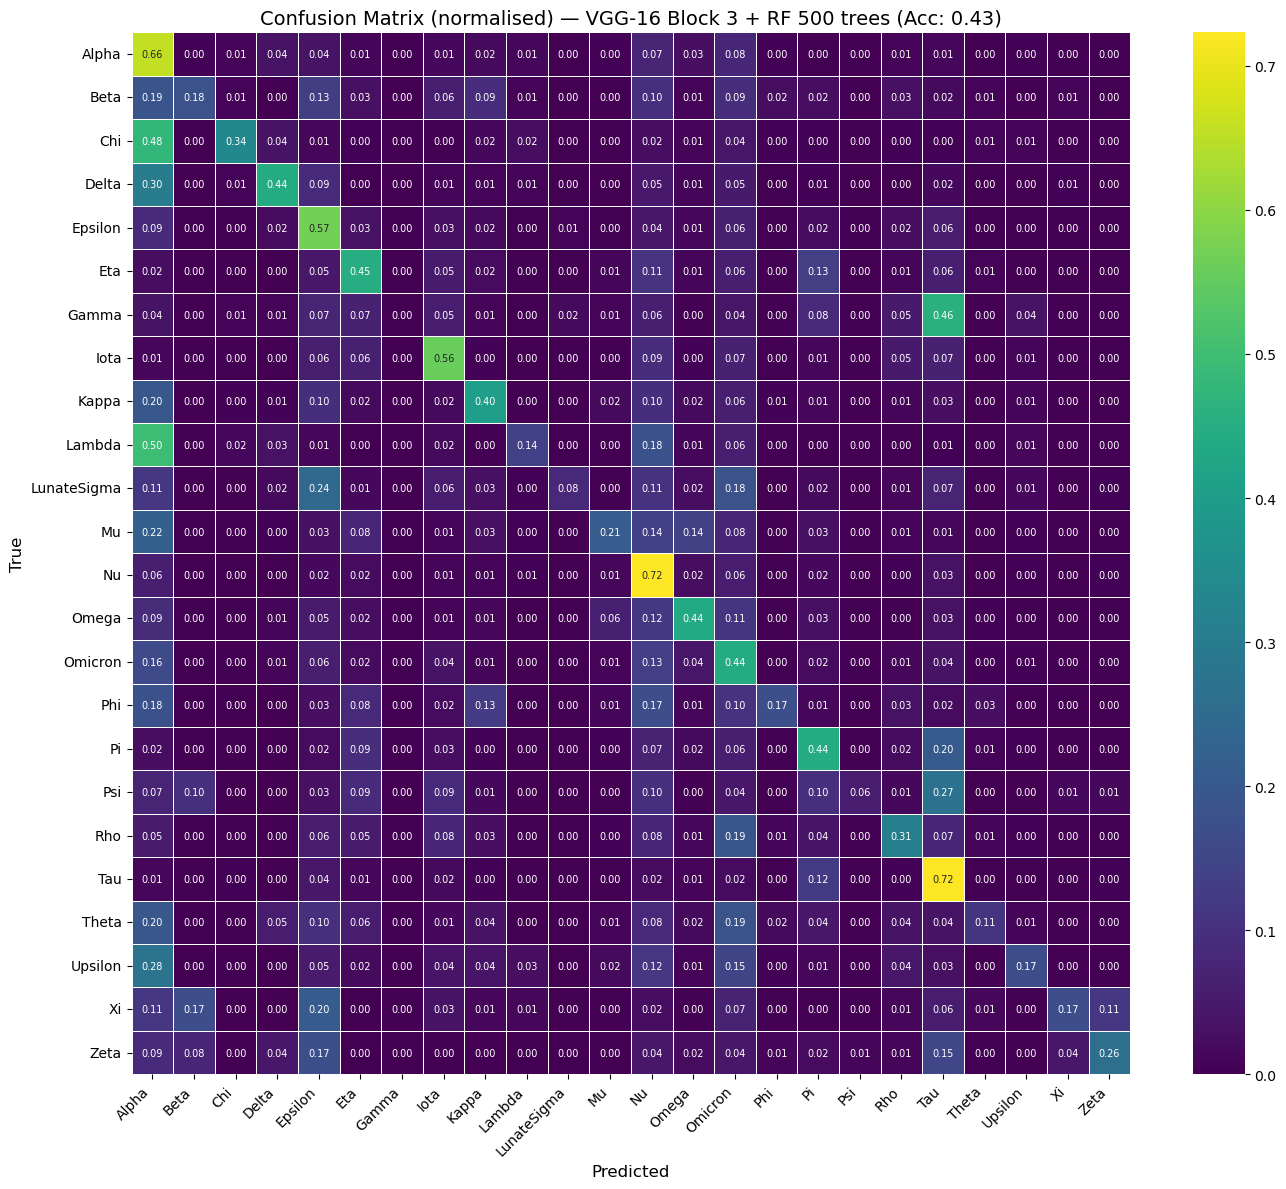

In [2]:
#1.1

"""
Random Forest Classifier for Greek Letters
-------------------------------------------
Loads the 256-d VGG-16 features and trains a Random Forest.
Class imbalance is handled via class_weight="balanced".
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block3pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block3pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────
#
# This dictionary will populate the "Overview" tab in your W&B dashboard.
# Every key here becomes a searchable, comparable column across all your runs,
# letting you filter and sort across your two main experiment axes:
#   • VGG-16 cut point  (block3 / block4 / block5)
#   • Classifier type   (RandomForest / BalancedRandomForest)
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "model_type"     → was "SVC", now "RandomForestClassifier"
#   "n_estimators"   → replaces "kernel"/"C"/"gamma" (not applicable to RF)
#   "class_weight"   → kept identical; same imbalance strategy
#   "n_jobs"         → replaces "cache_size" (RF uses CPU cores, not RAM cache)
#   "test_size"      → kept identical; same split ratio
#   "random_state"   → kept identical; same reproducibility seed
#   "vgg16_block"    → kept identical; block cut point
#
# ── New keys (added to make all 10 runs comparable in the dashboard) ──────────
#   "feature_dim"          → 256 for block3, 512 for block4/block5.
#                            Flows from the block choice; lets you immediately
#                            see how input size correlates with performance.
#
#   "imbalance_strategy"   → one of: "class_weight" | "balanced_bootstrap" |
#                            "smote+balanced_subsample".
#                            You used three different approaches across runs —
#                            without this key they look identical in the table.
#
#   "smote_target"         → the minority-class sample target when SMOTE is used
#                            (2000 in runs 2 & 3), or None when not used.
#                            Lets you see whether the synthetic data volume
#                            affected results independently of the classifier.
#
#   "min_samples_leaf"     → varied across runs (1, 2, 4, 8). Controls how
#                            fine-grained the leaf nodes are — higher values
#                            smooth decision boundaries and reduce overfitting.
#                            Currently invisible in W&B without this key.
#
#   "max_features"         → varied across runs ("sqrt", "log2", 0.3, None).
#                            Controls how many features each split considers.
#                            Directly affects tree diversity and generalisation.
#
#   "max_depth"            → None (unlimited) in most runs, 25 in run 3.
#                            Without logging this you cannot tell which runs
#                            had depth-capped trees vs fully grown ones.
#
#   "leakage_free_scaling" → True in this script (split before scale).
#                            False in all original scripts (scale before split).
#                            Critical for interpreting metric differences across
#                            runs — a run with leakage will appear artificially
#                            better than one without.

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "RandomForestClassifier",
    "n_estimators":         500,          # number of trees
    "class_weight":         "balanced",   # compensates for 14.8x class imbalance
    "min_samples_leaf":     1,            # default; leaf must have ≥1 sample
    "max_features":         "sqrt",       # default for RF classifiers
    "max_depth":            None,         # unlimited tree depth (default)
    "n_jobs":               -1,           # use all CPU cores

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          3,            # VGG-16 cut point (3 / 4 / 5)
    "feature_dim":          256,          # 256 for block3, 512 for block4/block5

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "class_weight",  # "class_weight" | "balanced_bootstrap"
                                             # | "smote+balanced_subsample"
    "smote_target":         None,            # None — SMOTE not used in this run

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,         # 80% train, 20% test
    "random_state":         42,           # fixed seed for full reproducibility
    "leakage_free_scaling": True,         # True = split first, then scale (correct)
                                          # False = original scripts (data leakage)
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────
#
# "project"   → unchanged: groups all runs under one project.
#
# "name"      → updated to follow a consistent convention across all 10 runs:
#               {model_type}_block{vgg16_block}_{imbalance_strategy}_trees{n_estimators}
#
#               This makes the runs table immediately readable — you can see
#               at a glance which block, which classifier, and which imbalance
#               strategy each run used without opening it.
#
#               Examples from your other scripts:
#                 RF_block3_classweight_trees500         ← this run
#                 BRF_block3_smote_trees500
#                 BRF_block3_smote_trees700
#                 RF_block4_classweight_trees500
#                 BRF_block4_bootstrap_trees500
#                 BRF_block4_bootstrap_trees1000
#                 BRF_block5_bootstrap_trees500
#                 RF_block5_classweight_trees500
#
# "job_type"  → unchanged: "modeling" tags this as a training run.
# "config"    → unchanged: passes all hyperparameters from the first line.

wandb.init(
    project  = "odysseus",
    name     = "RF_block3_classweight_trees500",   # convention: {type}_block{N}_{strategy}_trees{N}
    job_type = "modeling",
    config   = config_params
)

# Map the tracked config back to a local variable for clean instantiation.
# If a W&B sweep overrides a value (e.g. sets n_estimators=1000),
# this variable will reflect that override — not the original dict above.
config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 256)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

# Reverse the dict so we can go from integer → letter name
# e.g. {0: "Alpha", 1: "Beta", ...}
index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

# stratify=labels ensures each class keeps its original proportion in both splits.
# e.g. if Psi is 0.6% of total, it stays 0.6% in both train and test.
# test_size and random_state are read from config (W&B-tracked) rather than
# hard-coded — same pattern as the colleague's code.
#
# The split happens BEFORE scaling (see Step 3).
# This is the correct order — see the explanation below.

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

# WHAT IS A SCALER?
# -----------------
# Your 256 VGG-16 features have very different numeric ranges — some sit near 0,
# others can reach ~3462. A StandardScaler is a per-feature normaliser: for each
# of the 256 columns it computes the mean and standard deviation across all
# training samples, then subtracts the mean and divides by the std.
# The result is that every feature ends up with mean ≈ 0 and std ≈ 1.
# This puts all 256 features on equal footing so no single large-valued feature
# dominates the model's decision-making.
#
# WHY THE ORDER MATTERS (data leakage fix):
# -----------------------------------------
# Previously, scaler.fit_transform(features) was called on the FULL dataset
# before the split. That means the scaler's mean/std were computed using test
# samples too — the model was indirectly "peeking" at test data during training.
# This is called data leakage and causes over-optimistic metrics at evaluation.
#
# The correct order (used here, and by the colleague's code) is:
#   1. fit_transform on X_train → scaler learns mean/std from training data only
#   2. transform on X_test      → applies those SAME training statistics to test
#
# The test set is treated as if it were brand-new, unseen data — which is what
# it should simulate.

print("\nScaling features...")

scaler        = StandardScaler()
X_train       = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test        = scaler.transform(X_test)         # apply train statistics to test only


# ── Step 4: Train Random Forest ────────────────────────────────────────────────

# All constructor arguments come from config (W&B-tracked) rather than
# magic numbers — same discipline as the colleague's SVC instantiation.
# class_weight="balanced" makes the RF automatically give more weight to
# rare classes (Psi=352 samples) and less to common ones (Alpha=5216).
# Without this, the RF would almost ignore rare classes.

print("\nTraining Random Forest (this may take a few minutes)...")

rf = RandomForestClassifier(
    n_estimators = config.n_estimators,   # tracked: 500 trees
    class_weight = config.class_weight,   # tracked: "balanced"
    random_state = config.random_state,   # tracked: 42
    n_jobs       = config.n_jobs          # tracked: -1 (all cores)
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

# Compute all metrics using sklearn functions (consistent with colleague's style)
accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# Per-class F1 — array of length 24, one score per Greek letter.
# Used below for two purposes:
#   1. Logged as a W&B Table so you can compare every class across all runs.
#   2. Identifies the single worst-performing class, which is more informative
#      than macro F1 alone for catching a completely abandoned minority class.
per_class_f1   = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

# Per-class precision, recall and F1 — important for imbalanced datasets.
# A high overall accuracy can hide poor performance on rare classes.
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────
#
# wandb.run.summary permanently pins these scalars to the run-table in the
# W&B dashboard — they stay visible even after the run finishes and let you
# sort/compare all runs at a glance.
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "final_accuracy"    → overall fraction of correctly classified test samples
#   "final_macro_f1"    → average F1 across all 24 classes (equal class weight)
#   "final_weighted_f1" → average F1 weighted by class size
#
# ── New keys ──────────────────────────────────────────────────────────────────
#   "final_worst_class_f1"   → F1 of the single worst-performing class.
#                              Since you care about rare classes (Psi, Xi),
#                              this pinpoints whether any class is being
#                              abandoned even when macro F1 looks acceptable.
#
#   "final_worst_class_name" → Name of that class (e.g. "Psi", "Xi").
#                              Lets you see in the runs table whether it's
#                              always the same letter struggling across blocks
#                              and classifier types.
#
#   "n_train_samples"        → Training set size AFTER any SMOTE upsampling.
#                              Runs with SMOTE have more samples than runs
#                              without — logging this lets you separate the
#                              effect of data volume from model choice.
#
#   "n_test_samples"         → Test set size. Should be ~11066 across all runs
#                              (20% of 55329) — logging it confirms consistency.

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────
#
# wandb.Table creates an interactive table visible in the W&B run page.
# Each row is one Greek letter and its F1 score for this run.
#
# Why this matters: the classification_report above only prints to terminal
# and is lost after the run. The W&B Table persists and — crucially — lets
# you open two runs side by side and see exactly which letters improved or
# regressed when you changed the block or classifier. This is the most
# useful addition for your specific experiment structure.
#
# wandb.log (not .summary) is correct here: Tables are media objects,
# same pattern as the confusion matrix image below.

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")

print(f"Saved: random_forest.pkl and scaler.pkl to {OUTPUT_DIR}/")


# ── 10. Generate and Log Annotated Heatmap ────────────────────────────────────
#
# confusion_matrix returns a 24×24 grid where:
#   rows = true class, columns = predicted class
#   diagonal = correct predictions, off-diagonal = mistakes
# Normalise each row to 0–1 so all classes are comparable regardless of size
# (without this, Alpha's large count would visually dominate the rare classes).
#
# cmap change: "Blues" (white→blue) → "viridis" (dark purple→green→yellow).
# "viridis" is perceptually uniform and works well for normalised matrices —
# low values (misclassifications) appear dark purple, high values (correct
# predictions) appear bright yellow.

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,            # show the probability inside each cell
    fmt          = ".2f",           # 2 decimal places
    cmap         = "viridis",        # dark purple (0) → yellow (1)
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},     # keeps numbers readable across all 576 cells
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 3 + RF {config.n_estimators} trees"
    f" (Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save to disk first, then log to W&B as an Image artifact.
# wandb.log (not .summary) is correct here — files/images are logged
# this way in the colleague's code and it keeps the image browsable in the
# W&B Media panel.
CM_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

# ── Close the W&B run ─────────────────────────────────────────────────────────
# wandb.finish() is called BEFORE plt.show() intentionally.
# plt.show() can block execution in non-interactive / server environments,
# which would leave the W&B run permanently open (zombie run in the dashboard).
# The PNG is already saved and logged above, so finishing here is safe.
wandb.finish()

plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest.pkl")
#   scaler = joblib.load("OUTPUT/scaler.pkl")
#
#   feature_vector = ...            # your 256-d vector from the extractor
#   feature_scaled = scaler.transform([feature_vector])
#   prediction     = rf.predict(feature_scaled)
#   print(class_names[prediction[0]])

Loading features and labels...
Features shape : (55329, 256)
Labels shape   : (55329,)

Before SMOTE:
  Train set : 44263 images
  Test set  : 11066 images

Scaling features...

SMOTE upsampling classes below 2000 samples:
  Beta            657 → 2000
  Chi             1213 → 2000
  Delta           1505 → 2000
  Gamma           663 → 2000
  Iota            1733 → 2000
  Lambda          1416 → 2000
  LunateSigma     1611 → 2000
  Mu              1909 → 2000
  Phi             894 → 2000
  Psi             282 → 2000
  Rho             1792 → 2000
  Theta           1117 → 2000
  Upsilon         1872 → 2000
  Xi              353 → 2000
  Zeta            367 → 2000

After SMOTE:
  Train set : 56879 images

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 38.90%
Macro-F1         : 0.3609
Weighted-F1      : 0.3633
Worst class      : Omicron (F1 = 0.0714)

Per-class report:
              precision    recall  f1-score   

final_accuracy,0.38903
final_macro_f1,0.36094
final_weighted_f1,0.36328
final_worst_class_f1,0.07136
final_worst_class_name,Omicron
n_test_samples,11066
n_train_samples,56879


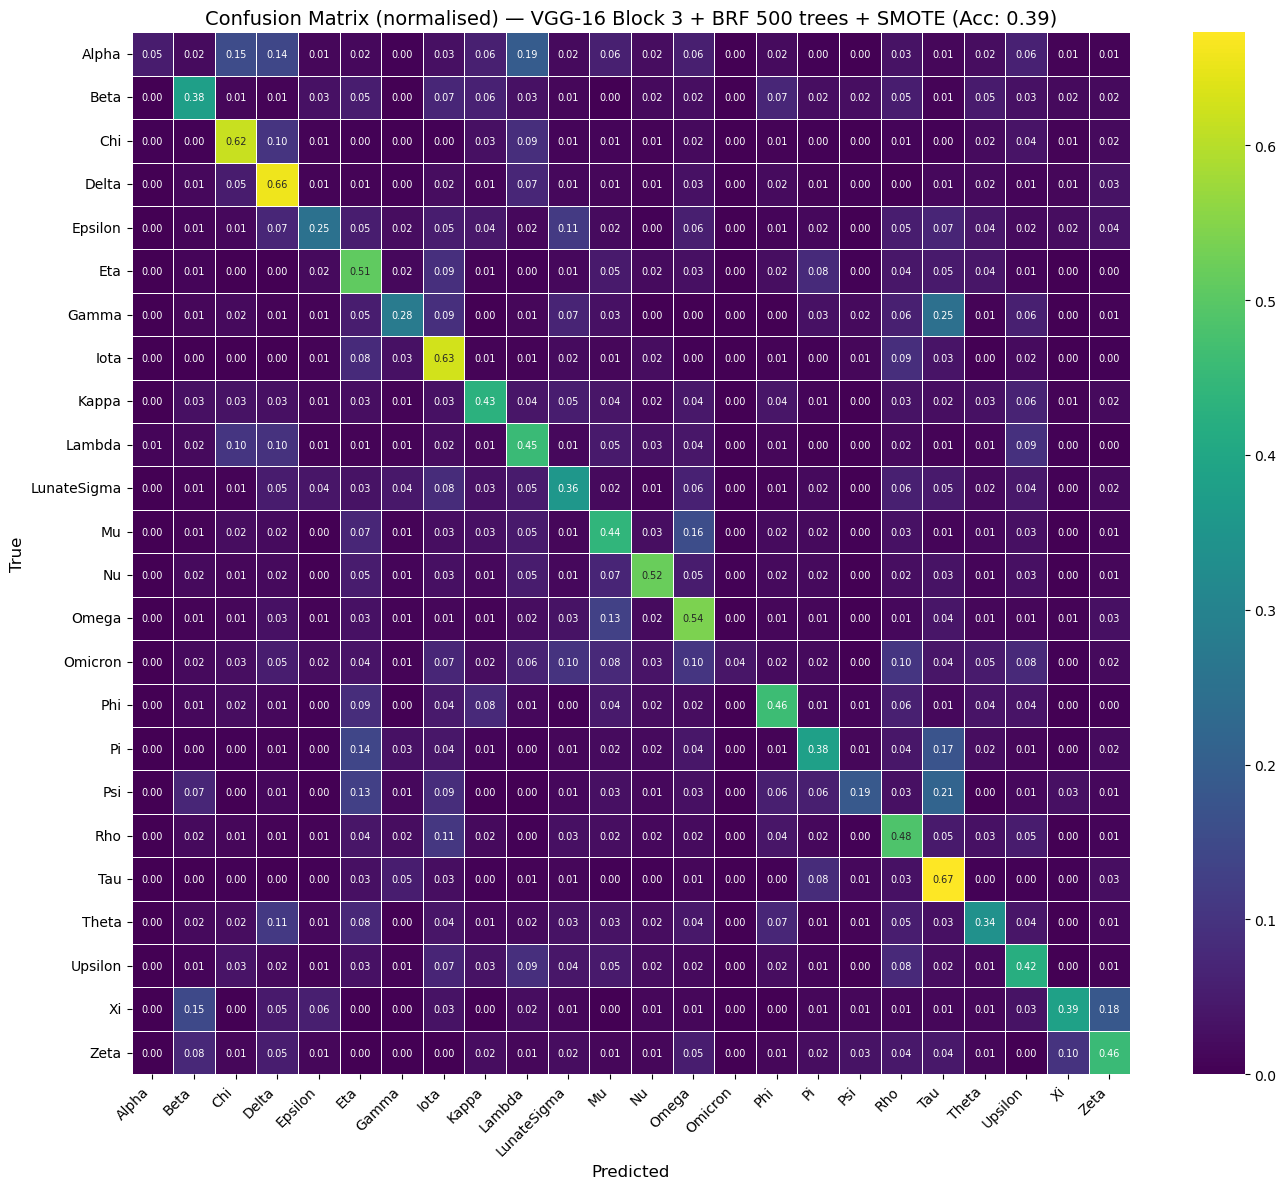

In [3]:
#2.1 

"""
Balanced Random Forest Classifier for Greek Letters — Script #2
-----------------------------------------------------------------
Loads 256-d VGG-16 block3 features, applies SMOTE to minority classes
in the training set only, then trains a BalancedRandomForestClassifier
with class_weight="balanced_subsample".
Outputs: model, scaler, confusion matrix heatmap, W&B run.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier  # ← replaces RandomForestClassifier
from imblearn.over_sampling import SMOTE                      # ← new: synthetic minority oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block3pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block3pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"

# Classes below this count will be upsampled by SMOTE.
# Set to the approximate median class size (~2000) so only clearly
# underrepresented classes are touched; large classes are left unchanged.
SMOTE_TARGET = 2000


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────
#
# This dictionary will populate the "Overview" tab in your W&B dashboard.
# Every key here becomes a searchable, comparable column across all your runs,
# letting you filter and sort across your two main experiment axes:
#   • VGG-16 cut point  (block3 / block4 / block5)
#   • Classifier type   (RandomForest / BalancedRandomForest)
#
# ── Keys that changed vs script #1 ────────────────────────────────────────────
#   "model_type"         → "RandomForestClassifier" → "BalancedRandomForestClassifier"
#                          The BRF draws a balanced bootstrap per tree, giving
#                          minority classes equal representation in every tree.
#
#   "class_weight"       → "balanced" → "balanced_subsample"
#                          "balanced_subsample" recomputes class weights on each
#                          bootstrap sample (per tree) rather than on the full
#                          dataset. This is the correct setting for BRF because
#                          each tree already sees a different subset of the data.
#
#   "min_samples_leaf"   → 1 → 4
#                          Requiring at least 4 samples per leaf smooths decision
#                          boundaries and reduces overfitting to SMOTE artefacts,
#                          which tend to form tight synthetic micro-clusters.
#
#   "max_features"       → "sqrt" → "sqrt" (kept, but now explicitly documented
#                          as intentional — sqrt(256) ≈ 16 features per split)
#
#   "imbalance_strategy" → "class_weight" → "smote+balanced_subsample"
#                          Two complementary layers: SMOTE adds synthetic samples
#                          to training data before fitting; balanced_subsample
#                          then reweights inside every tree's bootstrap draw.
#
#   "smote_target"       → None → 2000
#                          Any class with fewer than 2000 training samples is
#                          upsampled to exactly 2000 by SMOTE. Classes above
#                          2000 are left completely untouched.
#
# ── Keys that stayed the same ─────────────────────────────────────────────────
#   "n_estimators", "n_jobs", "vgg16_block", "feature_dim",
#   "test_size", "random_state", "max_depth", "leakage_free_scaling"

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",  # ← changed
    "n_estimators":         500,
    "class_weight":         "balanced_subsample",  # ← changed: per-tree reweighting
    "min_samples_leaf":     4,                     # ← changed: smooths SMOTE artefacts
    "max_features":         "sqrt",                # sqrt(256) ≈ 16 features per split
    "max_depth":            None,                  # unlimited tree depth
    "n_jobs":               -1,

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          3,
    "feature_dim":          256,

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "smote+balanced_subsample",  # ← changed
    "smote_target":         SMOTE_TARGET,                # ← changed: 2000

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,
    "random_state":         42,
    "leakage_free_scaling": True,
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────
#
# "name" follows the same convention as all other runs:
#   {model_type}_block{vgg16_block}_{imbalance_strategy}_trees{n_estimators}
#
#   BRF_block3_smote_trees500          ← this run
#   RF_block3_classweight_trees500     ← script #1
#   BRF_block3_smote_trees700          ← script #3
#   RF_block4_classweight_trees500     ← script #6
#   BRF_block4_bootstrap_trees500      ← script #7
#   BRF_block4_bootstrap_trees1000     ← script #8
#   BRF_block5_bootstrap_trees500      ← script #9
#   RF_block5_classweight_trees500     ← script #10

wandb.init(
    project  = "odysseus",
    name     = "BRF_block3_smote_trees500",  # ← changed
    job_type = "modeling",
    config   = config_params
)

# Map the tracked config back to a local variable for clean instantiation.
# If a W&B sweep overrides a value (e.g. sets n_estimators=1000),
# this variable will reflect that override — not the original dict above.
config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 256)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

# Reverse the dict so we can go from integer → letter name
# e.g. {0: "Alpha", 1: "Beta", ...}
index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

# stratify=labels ensures each class keeps its original proportion in both splits.
# e.g. if Psi is 0.6% of total, it stays 0.6% in both train and test.
# test_size and random_state are read from config (W&B-tracked).
#
# IMPORTANT: the split happens BEFORE both scaling and SMOTE.
# SMOTE is applied only to X_train (Step 4), never to X_test.
# X_test must remain entirely original to simulate real unseen data.

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"\nBefore SMOTE:")
print(f"  Train set : {X_train.shape[0]} images")
print(f"  Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

# WHAT IS A SCALER?
# -----------------
# Your 256 VGG-16 features have very different numeric ranges — some sit near 0,
# others can reach ~3462. A StandardScaler is a per-feature normaliser: for each
# of the 256 columns it computes the mean and standard deviation across all
# training samples, then subtracts the mean and divides by the std.
# The result is that every feature ends up with mean ≈ 0 and std ≈ 1.
# This puts all 256 features on equal footing so no single large-valued feature
# dominates the model's decision-making.
#
# WHY THE ORDER MATTERS (data leakage fix):
# -----------------------------------------
# The correct order (used here) is:
#   1. fit_transform on X_train → scaler learns mean/std from training data only
#   2. transform on X_test      → applies those SAME training statistics to test
#
# Scaling is done BEFORE SMOTE (Step 4) so that SMOTE interpolates in the
# same normalised feature space the model will train on. If you scaled after
# SMOTE, synthetic samples would be generated in raw feature space and then
# rescaled, which is equivalent but less intuitive.

print("\nScaling features...")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test  = scaler.transform(X_test)        # apply train statistics to test only


# ── Step 4: Apply SMOTE to training set only ───────────────────────────────────

# WHAT IS SMOTE?
# --------------
# SMOTE (Synthetic Minority Over-sampling TEchnique) addresses class imbalance
# by creating new synthetic training samples for minority classes — it does NOT
# duplicate existing ones. For each minority sample, SMOTE finds its k nearest
# neighbours and generates a new point somewhere along the line connecting them.
# The result is a smoother, denser decision region for rare classes.
#
# WHY TRAIN ONLY?
# ---------------
# SMOTE is applied exclusively to X_train. X_test is never touched.
# Adding synthetic samples to the test set would make metrics meaningless —
# you would be evaluating performance on data that doesn't exist in reality.
#
# SELECTIVE UPSAMPLING:
# ----------------------
# Only classes below SMOTE_TARGET (2000) are upsampled. Classes above it
# (Alpha=5216, Nu=4859, Omicron=4958) are left completely unchanged.
# This avoids over-generating synthetic samples for already large classes
# and keeps the training distribution closer to the real one.

unique, counts = np.unique(y_train, return_counts=True)

# Build a dict: {class_integer: target_count} for minority classes only
sampling_strategy = {
    cls: config.smote_target
    for cls, count in zip(unique, counts)
    if count < config.smote_target    # only touch classes below the threshold
}

print(f"\nSMOTE upsampling classes below {config.smote_target} samples:")
for cls, target in sampling_strategy.items():
    original = counts[unique == cls][0]
    print(f"  {index_to_class[cls]:<15} {original} → {target}")

smote = SMOTE(
    sampling_strategy = sampling_strategy,
    random_state      = config.random_state   # tracked: 42
)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train set : {X_train.shape[0]} images")


# ── Step 5: Train Balanced Random Forest ──────────────────────────────────────

# HOW BalancedRandomForestClassifier DIFFERS FROM RandomForestClassifier:
# -----------------------------------------------------------------------
# A regular RF grows each tree on a random bootstrap sample drawn from the
# full training set. Because majority classes dominate that sample, minority
# classes (even after SMOTE) can still be underrepresented in individual trees.
#
# BalancedRandomForestClassifier fixes this by drawing a BALANCED bootstrap
# per tree — it samples the same number of examples from every class before
# growing each tree. Combined with SMOTE pre-processing, this gives two
# complementary layers of imbalance correction:
#   • SMOTE: adds synthetic minority samples to the pool before training starts
#   • BRF:   ensures every single tree sees equal class representation
#
# All constructor arguments come from config (W&B-tracked).

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

brf = BalancedRandomForestClassifier(
    n_estimators      = config.n_estimators,      # tracked: 500 trees
    class_weight      = config.class_weight,      # tracked: "balanced_subsample"
    min_samples_leaf  = config.min_samples_leaf,  # tracked: 4
    max_features      = config.max_features,      # tracked: "sqrt"
    max_depth         = config.max_depth,         # tracked: None
    sampling_strategy = "auto",   # BRF internal: balances each tree's bootstrap
    replacement       = False,    # sample without replacement per tree
    random_state      = config.random_state,      # tracked: 42
    n_jobs            = config.n_jobs             # tracked: -1 (all cores)
)

brf.fit(X_train, y_train)
print("Training done.")


# ── Step 6: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = brf.predict(X_test)

# Compute all metrics using sklearn functions (consistent with colleague's style)
accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# Per-class F1 — array of length 24, one score per Greek letter.
# Used below for two purposes:
#   1. Logged as a W&B Table so you can compare every class across all runs.
#   2. Identifies the single worst-performing class, which is more informative
#      than macro F1 alone for catching a completely abandoned minority class.
per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

# Per-class precision, recall and F1 — important for imbalanced datasets.
# A high overall accuracy can hide poor performance on rare classes.
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────
#
# wandb.run.summary permanently pins these scalars to the run-table in the
# W&B dashboard — they stay visible even after the run finishes and let you
# sort/compare all runs at a glance.
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "final_accuracy"    → overall fraction of correctly classified test samples
#   "final_macro_f1"    → average F1 across all 24 classes (equal class weight)
#   "final_weighted_f1" → average F1 weighted by class size
#
# ── New keys ──────────────────────────────────────────────────────────────────
#   "final_worst_class_f1"   → F1 of the single worst-performing class.
#                              Since you care about rare classes (Psi, Xi),
#                              this pinpoints whether any class is being
#                              abandoned even when macro F1 looks acceptable.
#
#   "final_worst_class_name" → Name of that class (e.g. "Psi", "Xi").
#                              Lets you see in the runs table whether it's
#                              always the same letter struggling across blocks
#                              and classifier types.
#
#   "n_train_samples"        → Training set size AFTER SMOTE upsampling.
#                              This run will have more training samples than
#                              script #1 — logging this separates the effect
#                              of data volume from model choice.
#
#   "n_test_samples"         → Test set size. Should be ~11066 — same as
#                              script #1 since SMOTE never touches X_test.

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]   # inflated by SMOTE
wandb.run.summary["n_test_samples"]         = X_test.shape[0]    # unchanged


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────
#
# wandb.Table creates an interactive table visible in the W&B run page.
# Each row is one Greek letter and its F1 score for this run.
#
# Why this matters: the classification_report above only prints to terminal
# and is lost after the run. The W&B Table persists and — crucially — lets
# you open this run and script #1 side by side to see exactly which letters
# improved when switching from RF+class_weight to BRF+SMOTE.

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 7: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filename updated to reflect the BRF model — avoids overwriting script #1's output
joblib.dump(brf,    f"{OUTPUT_DIR}/balanced_random_forest_block3.pkl")  # ← changed
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_block3.pkl")

print(f"Saved: balanced_random_forest_block3.pkl and scaler_block3.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Annotated Heatmap ────────────────────────────────────────
#
# confusion_matrix returns a 24×24 grid where:
#   rows = true class, columns = predicted class
#   diagonal = correct predictions, off-diagonal = mistakes
# Normalise each row to 0–1 so all classes are comparable regardless of size
# (without this, Alpha's large count would visually dominate the rare classes).
#
# cmap "viridis": dark purple (0) → green → yellow (1).
# Perceptually uniform — low values (misclassifications) appear dark,
# high values (correct predictions) appear bright.

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,
    fmt          = ".2f",
    cmap         = "viridis",
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},   # keeps numbers readable across all 576 cells
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 3 + BRF {config.n_estimators} trees + SMOTE"
    f" (Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save to disk first, then log to W&B as an Image artifact.
# Filename updated to avoid overwriting script #1's confusion matrix.
CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_brf_block3_smote.png"  # ← changed
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_brf_block3_smote.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

# ── Close the W&B run ─────────────────────────────────────────────────────────
# wandb.finish() is called BEFORE plt.show() intentionally.
# plt.show() can block execution in non-interactive / server environments,
# which would leave the W&B run permanently open (zombie run in the dashboard).
wandb.finish()

plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   brf    = joblib.load("OUTPUT/balanced_random_forest_block3.pkl")
#   scaler = joblib.load("OUTPUT/scaler_block3.pkl")
#
#   feature_vector = ...            # your 256-d vector from the extractor
#   feature_scaled = scaler.transform([feature_vector])
#   prediction     = brf.predict(feature_scaled)
#   print(class_names[prediction[0]])

Loading features and labels...
Features shape : (55329, 256)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Applying SMOTE to training set...
Train set after SMOTE : 56879 samples

Training Balanced Random Forest — tuned (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 35.93%
Macro-F1         : 0.3311
Weighted-F1      : 0.3299
Worst class      : Omicron (F1 = 0.0140)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.92      0.01      0.02      1043
        Beta       0.23      0.38      0.29       164
         Chi       0.31      0.62      0.42       303
       Delta       0.33      0.65      0.44       376
     Epsilon       0.72      0.19      0.30       784
         Eta       0.38      0.48      0.42       532
       Gamma       0.18      0.33      0.23       166
        Iota       0.34      0.65      0.45       433
       Kappa       0.54     

final_accuracy,0.3593
final_macro_f1,0.33105
final_weighted_f1,0.32986
final_worst_class_f1,0.01399
final_worst_class_name,Omicron
n_test_samples,11066
n_train_samples,56879


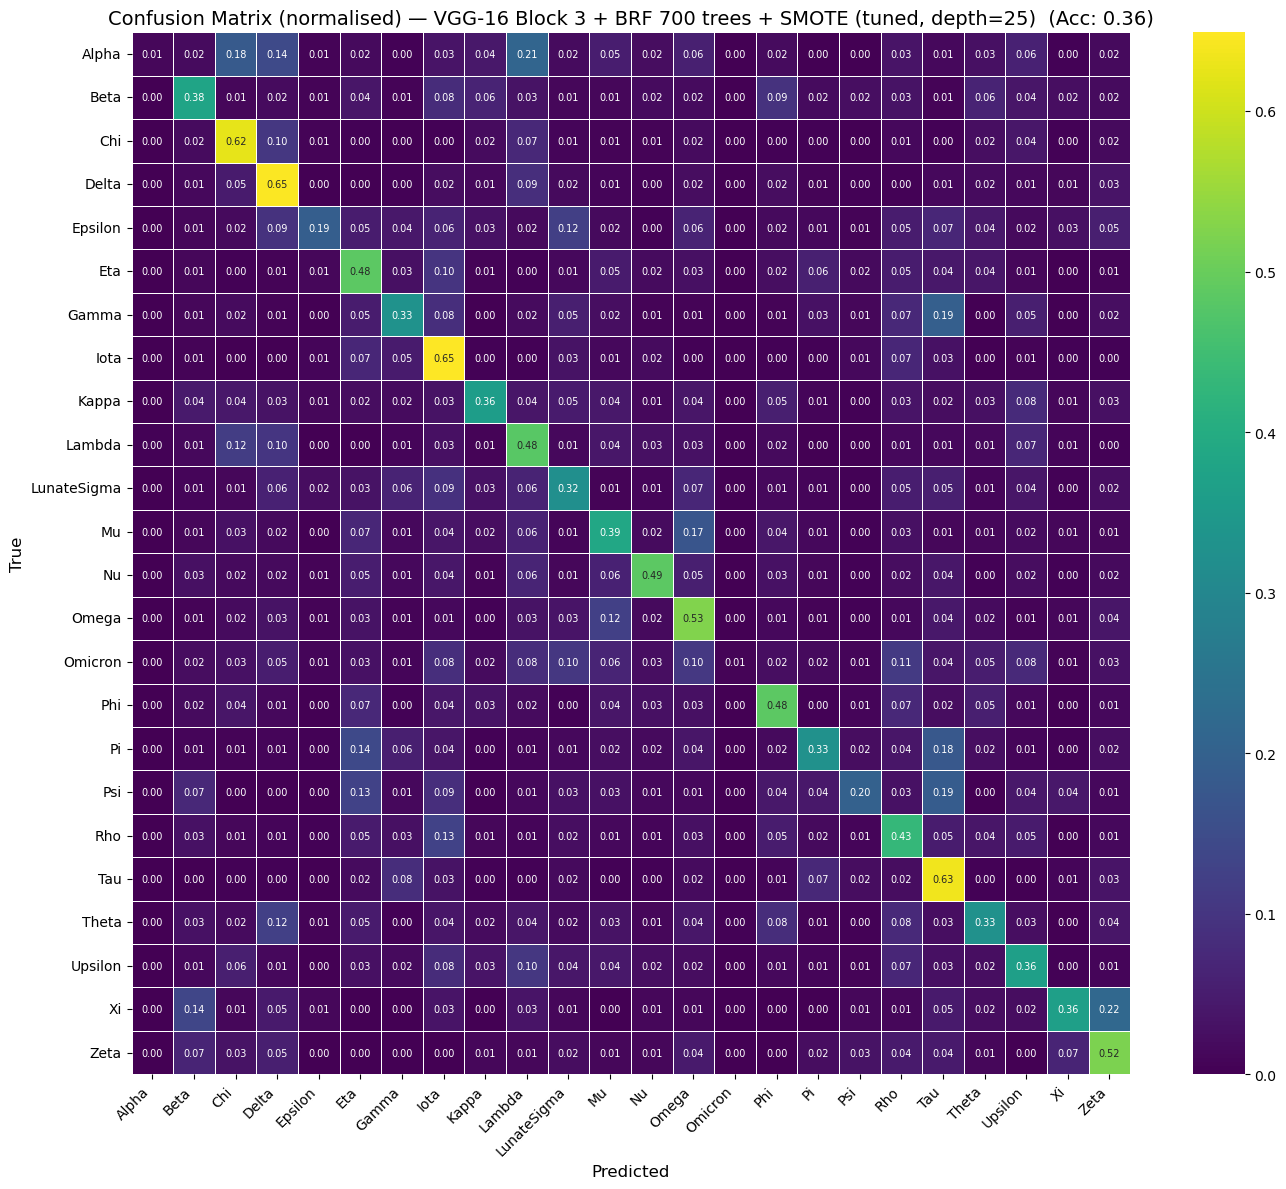

In [4]:
#3.1 

"""
Balanced Random Forest Classifier for Greek Letters (Block 3 + SMOTE, Tuned)
------------------------------------------------------------------------------
Same architecture as script 2 but with tuned hyperparameters:
  - n_estimators : 500 → 700
  - min_samples_leaf : 4 → 8  (stronger regularisation against SMOTE artefacts)
  - max_features : "sqrt" → "log2"  (more tree diversity)
  - max_depth : None → 25  (caps growth to prevent memorising synthetic samples)
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from collections import Counter
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block3pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block3pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         700,            # increased from 500
    "class_weight":         "balanced_subsample",
    "min_samples_leaf":     8,              # increased from 4 (stronger regularisation)
    "max_features":         "log2",         # changed from "sqrt" (more tree diversity)
    "max_depth":            25,             # capped from None (prevents SMOTE overfitting)
    "n_jobs":               -1,

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          3,
    "feature_dim":          256,

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "smote+balanced_subsample",
    "smote_target":         2000,

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,
    "random_state":         42,
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "BRF_block3_smote_trees700",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)
labels   = np.load(LABELS_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,
    random_state = config.random_state,
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

print("\nScaling features...")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ── Step 4: SMOTE oversampling ────────────────────────────────────────────────

print("\nApplying SMOTE to training set...")

class_counts = Counter(y_train)
sampling_strategy = {
    cls: config.smote_target
    for cls, count in class_counts.items()
    if count < config.smote_target
}

smote = SMOTE(
    sampling_strategy = sampling_strategy,
    random_state      = config.random_state
)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Train set after SMOTE : {X_train.shape[0]} samples")


# ── Step 5: Train Balanced Random Forest (tuned) ──────────────────────────────

print("\nTraining Balanced Random Forest — tuned (this may take a few minutes)...")

brf = BalancedRandomForestClassifier(
    n_estimators     = config.n_estimators,       # 700
    sampling_strategy= "all",
    replacement      = True,
    class_weight     = config.class_weight,
    min_samples_leaf = config.min_samples_leaf,   # 8
    max_features     = config.max_features,       # "log2"
    max_depth        = config.max_depth,           # 25
    random_state     = config.random_state,
    n_jobs           = config.n_jobs
)

brf.fit(X_train, y_train)
print("Training done.")


# ── Step 6: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = brf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 7: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(brf,    f"{OUTPUT_DIR}/balanced_random_forest_block3_smote_tuned.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_block3_smote_tuned.pkl")

print(f"Saved: balanced_random_forest_block3_smote_tuned.pkl and scaler to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 3 + BRF {config.n_estimators} trees "
    f"+ SMOTE (tuned, depth={config.max_depth})  (Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block3_smote_tuned.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block3_smote_tuned.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()


Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 51.98%
Macro-F1         : 0.4857
Weighted-F1      : 0.5228
Worst class      : Beta (F1 = 0.2921)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.77      0.21      0.33      1043
        Beta       0.20      0.52      0.29       164
         Chi       0.45      0.66      0.53       303
       Delta       0.50      0.73      0.60       376
     Epsilon       0.66      0.38      0.48       784
         Eta       0.54      0.62      0.58       532
       Gamma       0.26      0.54      0.35       166
        Iota       0.36      0.62      0.46       433
       Kappa       0.72      0.46      0.56       585
      Lambda       0.37      0.53      0.43       354
 Lun

final_accuracy,0.51979
final_macro_f1,0.48571
final_weighted_f1,0.52282
final_worst_class_f1,0.2921
final_worst_class_name,Beta
n_test_samples,11066
n_train_samples,44263


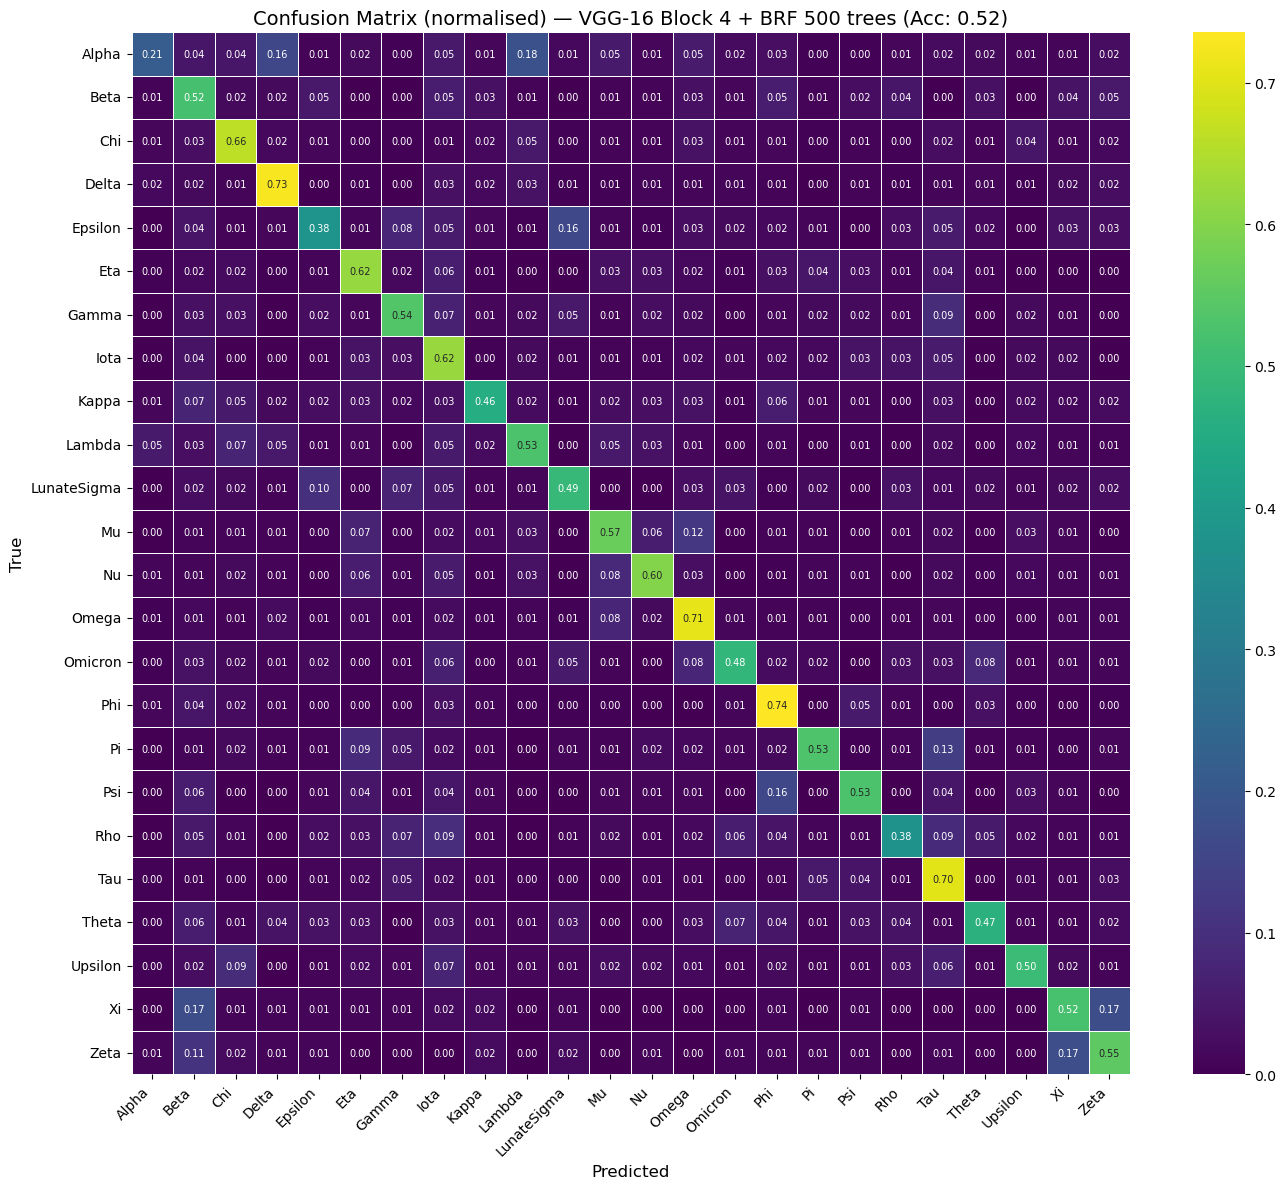

In [5]:
#4.1

"""
Balanced Random Forest Classifier for Greek Letters — VGG-16 Block 4
----------------------------------------------------------------------
Input stays block4 / 512-d. Classifier switches from RandomForestClassifier
(script 6) to BalancedRandomForestClassifier with default hyperparameters.
No SMOTE — imbalance is handled entirely by the balanced bootstrap inside the BRF.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block4pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block4pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         500,
    "class_weight":         "balanced_subsample",
    "min_samples_leaf":     1,          # default
    "max_features":         "sqrt",     # default
    "max_depth":            None,       # default
    "n_jobs":               -1,

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          4,
    "feature_dim":          512,

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap",   # no SMOTE
    "smote_target":         None,

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,
    "random_state":         42,
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "BRF_block4_bootstrap_trees500",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (N, 512)
labels   = np.load(LABELS_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,
    random_state = config.random_state,
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

print("\nScaling features...")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ── Step 4: Train Balanced Random Forest ──────────────────────────────────────
#
# No SMOTE here — the balanced bootstrap inside BRF handles imbalance by
# drawing equal numbers of samples from each class in every bootstrap round.

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

brf = BalancedRandomForestClassifier(
    n_estimators     = config.n_estimators,       # 500
    sampling_strategy= "all",
    replacement      = True,
    class_weight     = config.class_weight,        # "balanced_subsample"
    # min_samples_leaf, max_features, max_depth left at defaults
    random_state     = config.random_state,
    n_jobs           = config.n_jobs
)

brf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = brf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(brf,    f"{OUTPUT_DIR}/balanced_random_forest_block4.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_block4_brf.pkl")

print(f"Saved: balanced_random_forest_block4.pkl and scaler_block4_brf.pkl to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + BRF {config.n_estimators} trees"
    f" (Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_brf.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_brf.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()

Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest — tuned (this may take a while)...
Training done.

Evaluating on test set...
Overall accuracy : 47.77%
Macro-F1         : 0.4467
Weighted-F1      : 0.4765
Worst class      : Alpha (F1 = 0.1172)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.98      0.06      0.12      1043
        Beta       0.17      0.53      0.25       164
         Chi       0.45      0.65      0.53       303
       Delta       0.47      0.72      0.57       376
     Epsilon       0.78      0.29      0.43       784
         Eta       0.52      0.59      0.55       532
       Gamma       0.22      0.57      0.31       166
        Iota       0.37      0.63      0.47       433
       Kappa       0.65      0.43      0.52       585
      Lambda       0.30      0.55      0.39       354
 

final_accuracy,0.47768
final_macro_f1,0.44665
final_weighted_f1,0.47651
final_worst_class_f1,0.11722
final_worst_class_name,Alpha
n_test_samples,11066
n_train_samples,44263


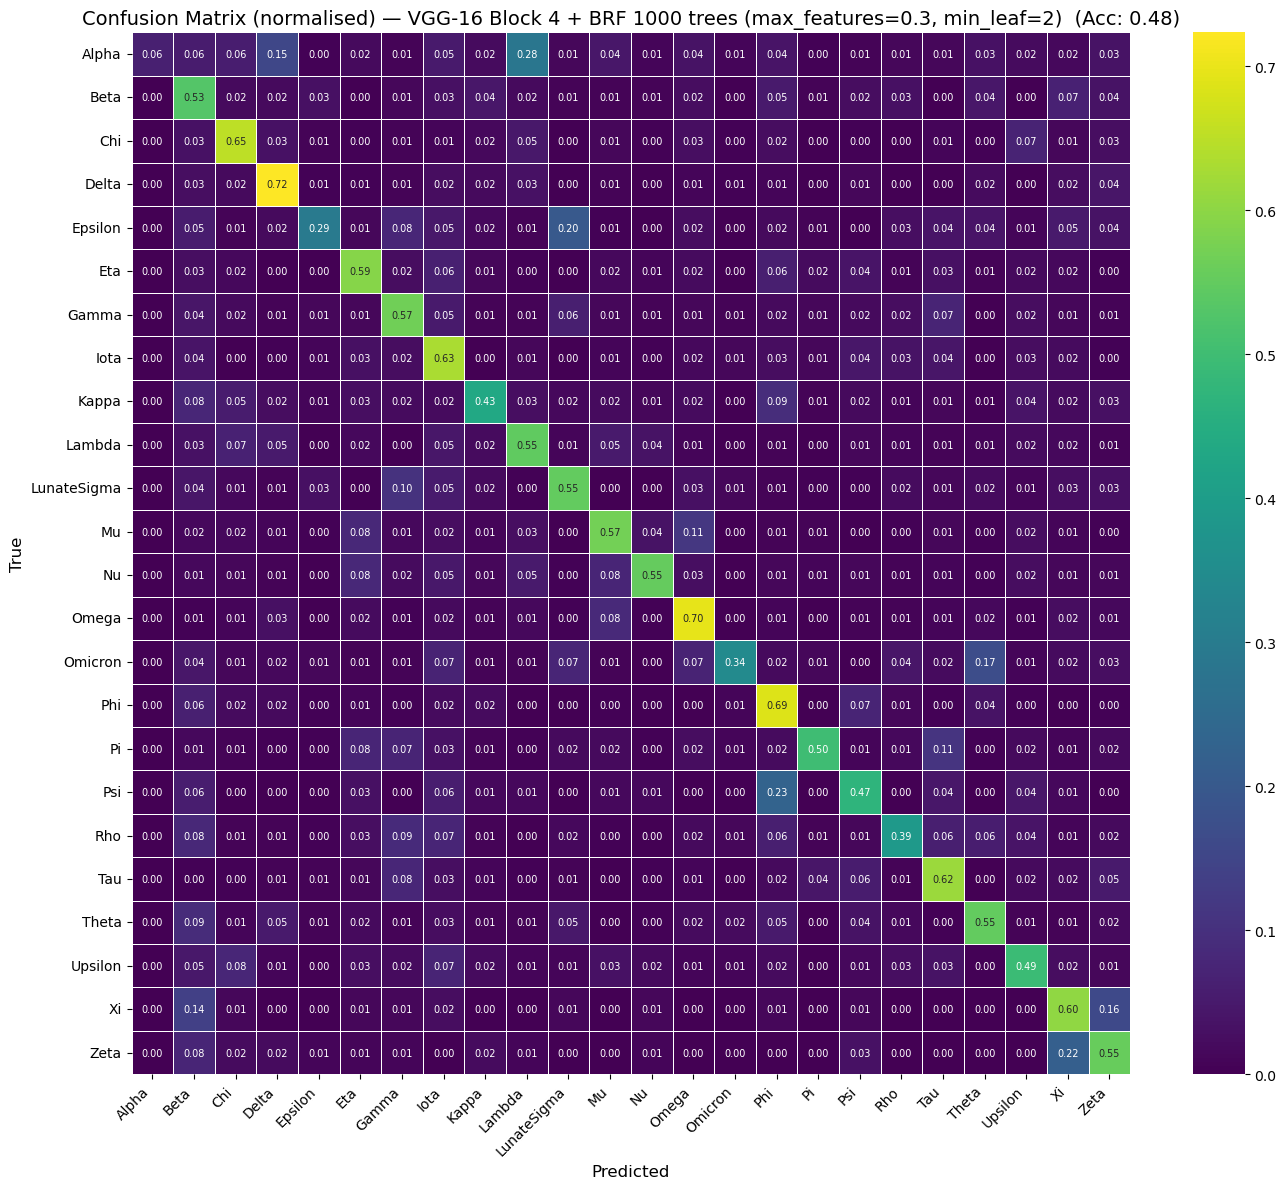

In [6]:
#5.1

"""
Balanced Random Forest Classifier for Greek Letters — VGG-16 Block 4 (Tuned)
------------------------------------------------------------------------------
Same block4 / BRF setup as script 7, with three tuned hyperparameters:
  - n_estimators  : 500 → 1000
  - max_features  : default → 0.3  (fractional: ~154 of 512 features per split)
  - min_samples_leaf : default (1) → 2
No SMOTE — balanced bootstrap only.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block4pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block4pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Hyperparameters ─────────────────────────────────────────────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         1000,           # increased from 500
    "class_weight":         "balanced_subsample",
    "min_samples_leaf":     2,              # increased from 1
    "max_features":         0.3,            # fractional: ~154 / 512 features per split
    "max_depth":            None,
    "n_jobs":               -1,

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          4,
    "feature_dim":          512,

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap",
    "smote_target":         None,

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,
    "random_state":         42,
    "leakage_free_scaling": True,
}


# ── 2. Initialize W&B ──────────────────────────────────────────────────────────

wandb.init(
    project  = "odysseus",
    name     = "BRF_block4_bootstrap_trees1000",
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (N, 512)
labels   = np.load(LABELS_FILE)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,
    random_state = config.random_state,
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

print("\nScaling features...")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ── Step 4: Train Balanced Random Forest (tuned) ──────────────────────────────

print("\nTraining Balanced Random Forest — tuned (this may take a while)...")

brf = BalancedRandomForestClassifier(
    n_estimators     = config.n_estimators,       # 1000
    sampling_strategy= "all",
    replacement      = True,
    class_weight     = config.class_weight,
    min_samples_leaf = config.min_samples_leaf,   # 2
    max_features     = config.max_features,        # 0.3
    max_depth        = config.max_depth,           # None
    random_state     = config.random_state,
    n_jobs           = config.n_jobs
)

brf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = brf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Summary Metrics to W&B ─────────────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(brf,    f"{OUTPUT_DIR}/balanced_random_forest_block4_tuned.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler_block4_brf_tuned.pkl")

print(f"Saved: balanced_random_forest_block4_tuned.pkl and scaler to {OUTPUT_DIR}/")


# ── Generate and Log Confusion Matrix ─────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot       = True,
    fmt         = ".2f",
    cmap        = "viridis",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 7},
    ax          = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + BRF {config.n_estimators} trees "
    f"(max_features={config.max_features}, min_leaf={config.min_samples_leaf})  "
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix_block4_brf_tuned.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix_block4_brf_tuned.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

wandb.finish()
plt.show()

Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 56.75%
Macro-F1         : 0.5211
Weighted-F1      : 0.5721
Worst class      : Psi (F1 = 0.2752)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.77      0.35      0.48      1043
        Beta       0.23      0.41      0.29       164
         Chi       0.51      0.64      0.57       303
       Delta       0.58      0.76      0.66       376
     Epsilon       0.68      0.53      0.60       784
         Eta       0.51      0.67      0.58       532
       Gamma       0.33      0.47      0.39       166
        Iota       0.41      0.63      0.50       433
       Kappa       0.72      0.52      0.60       585
      Lambda       0.40      0.52      0.45       354
 Luna

final_accuracy,0.5675
final_macro_f1,0.52111
final_weighted_f1,0.57207
final_worst_class_f1,0.27523
final_worst_class_name,Psi
n_test_samples,11066
n_train_samples,44263


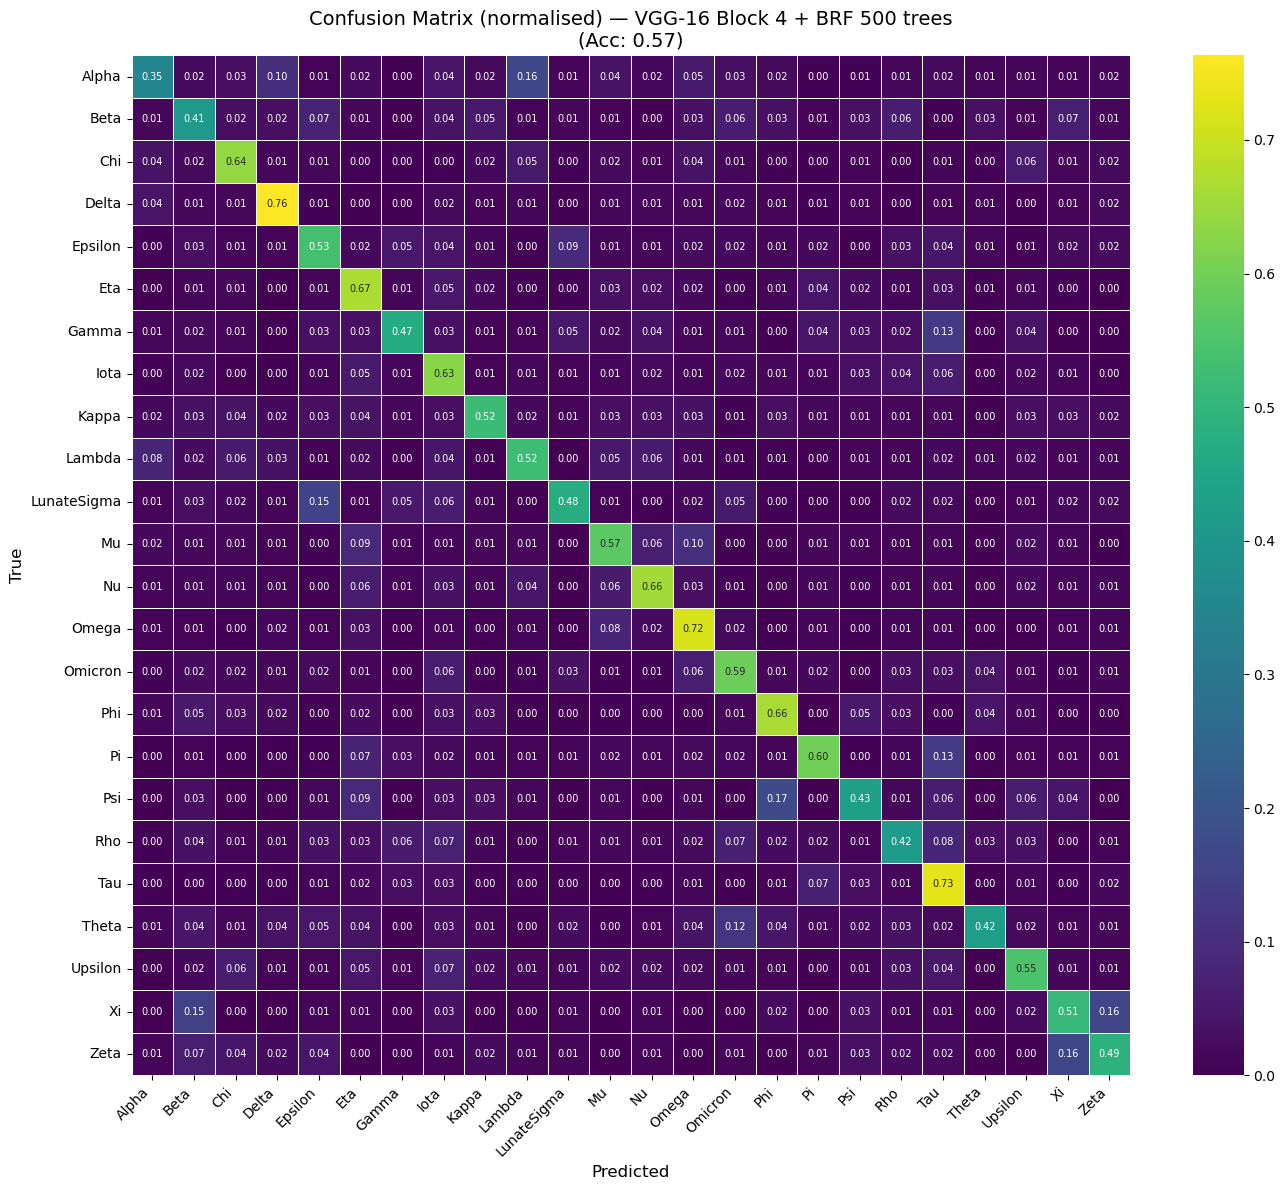

In [7]:
#6.1 
"""
Balanced Random Forest Classifier for Greek Letters
---------------------------------------------------
Loads the 512-d VGG-16 block 4 features and trains a BalancedRandomForestClassifier.
Class imbalance is handled via balanced bootstrap sampling.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block4pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block4pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         500,          # number of trees
    "min_samples_leaf":     1,            # default; leaf must have ≥1 sample
    "max_features":         "sqrt",       # default for RF classifiers
    "max_depth":            None,         # unlimited tree depth (default)
    "n_jobs":               -1,           # use all CPU cores

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          4,            # VGG-16 cut point
    "feature_dim":          512,          # 512 for block4

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap", # Strategy used by BRF
    "smote_target":         None,                 # None — SMOTE not used in this run

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,         # 80% train, 20% test
    "random_state":         42,           # fixed seed for full reproducibility
    "leakage_free_scaling": True,         # True = split first, then scale
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────

wandb.init(
    project  = "odysseus",
    name     = "BRF_block4_bootstrap_trees500",   # convention: {type}_block{N}_{strategy}_trees{N}
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 512)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

print("\nScaling features...")

scaler        = StandardScaler()
X_train       = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test        = scaler.transform(X_test)        # apply train statistics to test only


# ── Step 4: Train Balanced Random Forest ───────────────────────────────────────

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

rf = BalancedRandomForestClassifier(
    n_estimators = config.n_estimators,   # tracked: 500 trees
    random_state = config.random_state,   # tracked: 42
    n_jobs       = config.n_jobs          # tracked: -1 (all cores)
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")

print(f"Saved: random_forest.pkl and scaler.pkl to {OUTPUT_DIR}/")


# ── 10. Generate and Log Annotated Heatmap ────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,            
    fmt          = ".2f",           
    cmap         = "viridis",       
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},     
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + BRF {config.n_estimators} trees\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})
wandb.finish()

plt.show()

In [8]:
------------------------------------------

Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 56.03%
Macro-F1         : 0.5142
Weighted-F1      : 0.5665
Worst class      : Beta (F1 = 0.2876)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.77      0.36      0.49      1043
        Beta       0.23      0.39      0.29       164
         Chi       0.52      0.58      0.55       303
       Delta       0.56      0.72      0.63       376
     Epsilon       0.73      0.49      0.59       784
         Eta       0.50      0.65      0.56       532
       Gamma       0.29      0.48      0.36       166
        Iota       0.41      0.63      0.50       433
       Kappa       0.68      0.56      0.61       585
      Lambda       0.37      0.47      0.42       354
 Lun

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [ ]:
-----

Starting...


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\niric\_netrc.
wandb: Currently logged in as: ajeloukhova (ai-ml-universitaet-klagenfurt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 56.03%
Macro-F1         : 0.5142
Weighted-F1      : 0.5665
Worst class      : Beta (F1 = 0.2876)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.77      0.36      0.49      1043
        Beta       0.23      0.39      0.29       164
         Chi       0.52      0.58      0.55       303
       Delta       0.56      0.72      0.63       376
     Epsilon       0.73      0.49      0.59       784
         Eta       0.50      0.65      0.56       532
       Gamma       0.29      0.48      0.36       166
        Iota       0.41      0.63      0.50       433
       Kappa       0.68      0.56      0.61       585
      Lambda       0.37      0.47      0.42       354
 Lun

final_accuracy,0.56027
final_macro_f1,0.51417
final_weighted_f1,0.56649
final_worst_class_f1,0.28764
final_worst_class_name,Beta
n_test_samples,11066
n_train_samples,44263


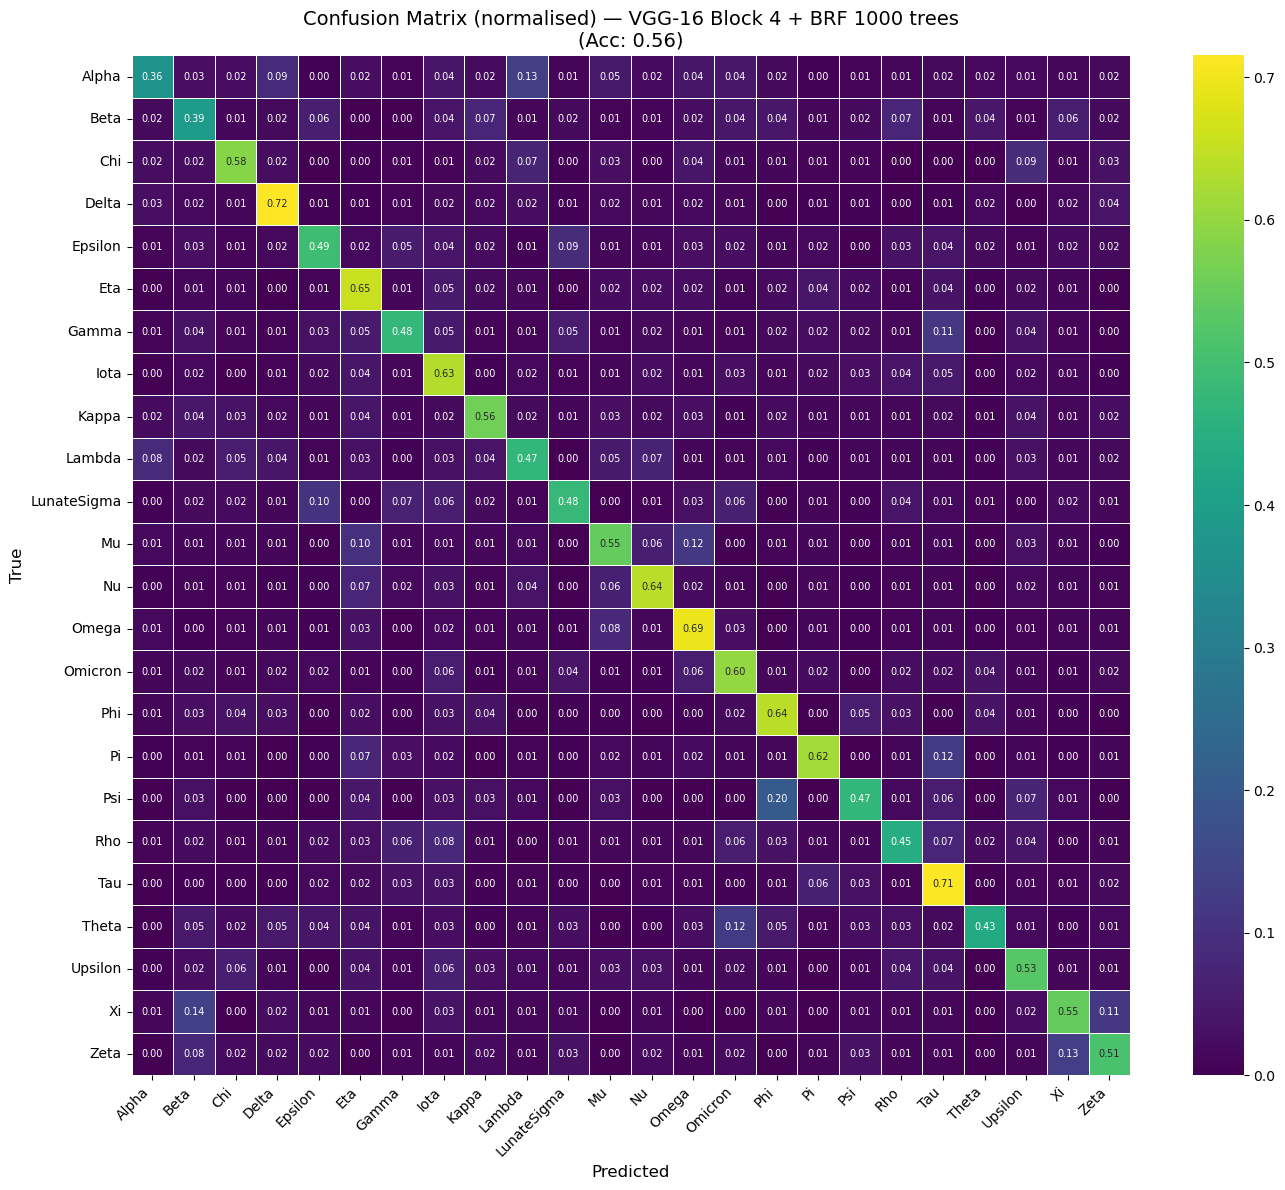

In [1]:
#7.1

"""
Balanced Random Forest Classifier for Greek Letters (Tuned)
-----------------------------------------------------------
Loads the 512-d VGG-16 block 4 features and trains a BalancedRandomForestClassifier.
Includes hyperparameter tuning (1000 trees, 0.3 max features, min_samples_leaf=2)
to provide stable votes for minority classes.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block4pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block4pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────
#
# This dictionary will populate the "Overview" tab in your W&B dashboard.
# Every key here becomes a searchable, comparable column across all your runs,
# letting you filter and sort across your two main experiment axes:
#   • VGG-16 cut point  (block3 / block4 / block5)
#   • Classifier type   (RandomForest / BalancedRandomForest)
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "model_type"    → was "SVC", now "BalancedRandomForestClassifier"
#   "n_estimators"  → replaces "kernel"/"C"/"gamma" (not applicable to RF)
#   "class_weight"  → removed; BRF handles imbalance natively via balanced bootstrap
#   "n_jobs"        → replaces "cache_size" (RF uses CPU cores, not RAM cache)
#   "test_size"     → kept identical; same split ratio
#   "random_state"  → kept identical; same reproducibility seed
#   "vgg16_block"   → kept identical; block cut point
#
# ── New keys (added to make all 10 runs comparable in the dashboard) ──────────
#   "feature_dim"          → 256 for block3, 512 for block4/block5.
#                            Flows from the block choice; lets you immediately
#                            see how input size correlates with performance.
#
#   "imbalance_strategy"   → one of: "class_weight" | "balanced_bootstrap" |
#                            "smote+balanced_subsample".
#                            You used three different approaches across runs —
#                            without this key they look identical in the table.
#
#   "smote_target"         → the minority-class sample target when SMOTE is used
#                            (2000 in runs 2 & 3), or None when not used.
#                            Lets you see whether the synthetic data volume
#                            affected results independently of the classifier.
#
#   "min_samples_leaf"     → varied across runs (1, 2, 4, 8). Controls how
#                            fine-grained the leaf nodes are — higher values
#                            smooth decision boundaries and reduce overfitting.
#                            Currently invisible in W&B without this key.
#
#   "max_features"         → varied across runs ("sqrt", "log2", 0.3, None).
#                            Controls how many features each split considers.
#                            Directly affects tree diversity and generalisation.
#
#   "max_depth"            → None (unlimited) in most runs, 25 in run 3.
#                            Without logging this you cannot tell which runs
#                            had depth-capped trees vs fully grown ones.
#
#   "leakage_free_scaling" → True in this script (split before scale).
#                            False in all original scripts (scale before split).
#                            Critical for interpreting metric differences across
#                            runs — a run with leakage will appear artificially
#                            better than one without.

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         1000,         # 500 -> 1000: more stable votes
    "min_samples_leaf":     2,            # 1 -> 2: smooths noisy splits
    "max_features":         0.3,          # considers ~154/512 features per split
    "max_depth":            None,         # unlimited tree depth (default)
    "n_jobs":               -1,           # use all CPU cores

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          4,            # VGG-16 cut point (3 / 4 / 5)
    "feature_dim":          512,          # 256 for block3, 512 for block4/block5

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap", # "class_weight" | "balanced_bootstrap"
                                                  # | "smote+balanced_subsample"
    "smote_target":         None,                 # None — SMOTE not used in this run

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,         # 80% train, 20% test
    "random_state":         42,           # fixed seed for full reproducibility
    "leakage_free_scaling": True,         # True = split first, then scale (correct)
                                          # False = original scripts (data leakage)
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────
#
# "project"   → unchanged: groups all runs under one project.
#
# "name"      → updated to follow a consistent convention across all 10 runs:
#               {model_type}_block{vgg16_block}_{imbalance_strategy}_trees{n_estimators}
#
#               This makes the runs table immediately readable — you can see
#               at a glance which block, which classifier, and which imbalance
#               strategy each run used without opening it.
#
#               Examples from your other scripts:
#                 RF_block3_classweight_trees500         
#                 BRF_block3_smote_trees500
#                 BRF_block3_smote_trees700
#                 RF_block4_classweight_trees500
#                 BRF_block4_bootstrap_trees500
#                 BRF_block4_bootstrap_trees1000         ← this run
#                 BRF_block5_bootstrap_trees500
#                 RF_block5_classweight_trees500
#
# "job_type"  → unchanged: "modeling" tags this as a training run.
# "config"    → unchanged: passes all hyperparameters from the first line.

print("Starting...")

wandb.init(
    project  = "odysseus",
    name     = "BRF_block4_bootstrap_trees1000_1",   # convention: {type}_block{N}_{strategy}_trees{N}
    job_type = "modeling",
    config   = config_params
)

# Map the tracked config back to a local variable for clean instantiation.
# If a W&B sweep overrides a value (e.g. sets n_estimators=1500),
# this variable will reflect that override — not the original dict above.
config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 512)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

# Reverse the dict so we can go from integer → letter name
# e.g. {0: "Alpha", 1: "Beta", ...}
index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

# stratify=labels ensures each class keeps its original proportion in both splits.
# e.g. if Psi is 0.6% of total, it stays 0.6% in both train and test.
# test_size and random_state are read from config (W&B-tracked) rather than
# hard-coded — same pattern as the colleague's code.
#
# The split happens BEFORE scaling (see Step 3).
# This is the correct order — see the explanation below.

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

# WHAT IS A SCALER?
# -----------------
# Your 512 VGG-16 features have very different numeric ranges — some sit near 0,
# others can reach ~3462. A StandardScaler is a per-feature normaliser: for each
# of the 512 columns it computes the mean and standard deviation across all
# training samples, then subtracts the mean and divides by the std.
# The result is that every feature ends up with mean ≈ 0 and std ≈ 1.
# This puts all 512 features on equal footing so no single large-valued feature
# dominates the model's decision-making.
#
# WHY THE ORDER MATTERS (data leakage fix):
# -----------------------------------------
# Previously, scaler.fit_transform(features) was called on the FULL dataset
# before the split. That means the scaler's mean/std were computed using test
# samples too — the model was indirectly "peeking" at test data during training.
# This is called data leakage and causes over-optimistic metrics at evaluation.
#
# The correct order (used here, and by the colleague's code) is:
#   1. fit_transform on X_train → scaler learns mean/std from training data only
#   2. transform on X_test      → applies those SAME training statistics to test
#
# The test set is treated as if it were brand-new, unseen data — which is what
# it should simulate.

print("\nScaling features...")

scaler        = StandardScaler()
X_train       = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test        = scaler.transform(X_test)        # apply train statistics to test only


# ── Step 4: Train Balanced Random Forest ───────────────────────────────────────

# All constructor arguments come from config (W&B-tracked) rather than
# magic numbers — same discipline as the colleague's SVC instantiation.
# BalancedRandomForestClassifier handles imbalance naturally via balanced 
# bootstrap samples, ensuring rare classes get equal representation in every tree.

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

rf = BalancedRandomForestClassifier(
    n_estimators     = config.n_estimators,     # tracked: 1000 trees
    max_features     = config.max_features,     # tracked: 0.3
    min_samples_leaf = config.min_samples_leaf, # tracked: 2
    random_state     = config.random_state,     # tracked: 42
    n_jobs           = config.n_jobs            # tracked: -1 (all cores)
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

# Compute all metrics using sklearn functions (consistent with colleague's style)
accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# Per-class F1 — array of length 24, one score per Greek letter.
# Used below for two purposes:
#   1. Logged as a W&B Table so you can compare every class across all runs.
#   2. Identifies the single worst-performing class, which is more informative
#      than macro F1 alone for catching a completely abandoned minority class.
per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

# Per-class precision, recall and F1 — important for imbalanced datasets.
# A high overall accuracy can hide poor performance on rare classes.
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────
#
# wandb.run.summary permanently pins these scalars to the run-table in the
# W&B dashboard — they stay visible even after the run finishes and let you
# sort/compare all runs at a glance.
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "final_accuracy"    → overall fraction of correctly classified test samples
#   "final_macro_f1"    → average F1 across all 24 classes (equal class weight)
#   "final_weighted_f1" → average F1 weighted by class size
#
# ── New keys ──────────────────────────────────────────────────────────────────
#   "final_worst_class_f1"   → F1 of the single worst-performing class.
#                              Since you care about rare classes (Psi, Xi),
#                              this pinpoints whether any class is being
#                              abandoned even when macro F1 looks acceptable.
#
#   "final_worst_class_name" → Name of that class (e.g. "Psi", "Xi").
#                              Lets you see in the runs table whether it's
#                              always the same letter struggling across blocks
#                              and classifier types.
#
#   "n_train_samples"        → Training set size AFTER any SMOTE upsampling.
#                              Runs with SMOTE have more samples than runs
#                              without — logging this lets you separate the
#                              effect of data volume from model choice.
#
#   "n_test_samples"         → Test set size. Should be ~11066 across all runs
#                              (20% of 55329) — logging it confirms consistency.

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────
#
# wandb.Table creates an interactive table visible in the W&B run page.
# Each row is one Greek letter and its F1 score for this run.
#
# Why this matters: the classification_report above only prints to terminal
# and is lost after the run. The W&B Table persists and — crucially — lets
# you open two runs side by side and see exactly which letters improved or
# regressed when you changed the block or classifier. This is the most
# useful addition for your specific experiment structure.
#
# wandb.log (not .summary) is correct here: Tables are media objects,
# same pattern as the confusion matrix image below.

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")

print(f"Saved: random_forest.pkl and scaler.pkl to {OUTPUT_DIR}/")


# ── 10. Generate and Log Annotated Heatmap ────────────────────────────────────
#
# confusion_matrix returns a 24×24 grid where:
#   rows = true class, columns = predicted class
#   diagonal = correct predictions, off-diagonal = mistakes
# Normalise each row to 0–1 so all classes are comparable regardless of size
# (without this, Alpha's large count would visually dominate the rare classes).
#
# cmap change: "Blues" (white→blue) → "viridis" (dark purple→green→yellow).
# "viridis" is perceptually uniform and works well for normalised matrices —
# low values (misclassifications) appear dark purple, high values (correct
# predictions) appear bright yellow.

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,             # show the probability inside each cell
    fmt          = ".2f",            # 2 decimal places
    cmap         = "viridis",        # dark purple (0) → yellow (1)
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},      # keeps numbers readable across all 576 cells
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 4 + BRF {config.n_estimators} trees\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save to disk first, then log to W&B as an Image artifact.
# wandb.log (not .summary) is correct here — files/images are logged
# this way in the colleague's code and it keeps the image browsable in the
# W&B Media panel.
CM_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

# ── Close the W&B run ─────────────────────────────────────────────────────────
# wandb.finish() is called BEFORE plt.show() intentionally.
# plt.show() can block execution in non-interactive / server environments,
# which would leave the W&B run permanently open (zombie run in the dashboard).
# The PNG is already saved and logged above, so finishing here is safe.
wandb.finish()

plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest.pkl")
#   scaler = joblib.load("OUTPUT/scaler.pkl")
#
#   feature_vector = ...            # your 512-d vector from the extractor
#   feature_scaled = scaler.transform([feature_vector])
#   prediction     = rf.predict(feature_scaled)
#   print(class_names[prediction[0]])

Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 42.23%
Macro-F1         : 0.3789
Weighted-F1      : 0.4252
Worst class      : Xi (F1 = 0.2000)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.58      0.28      0.38      1043
        Beta       0.16      0.29      0.21       164
         Chi       0.29      0.54      0.38       303
       Delta       0.40      0.56      0.47       376
     Epsilon       0.54      0.30      0.39       784
         Eta       0.38      0.50      0.43       532
       Gamma       0.24      0.25      0.24       166
        Iota       0.28      0.45      0.34       433
       Kappa       0.50      0.34      0.41       585
      Lambda       0.27      0.33      0.30       354
 Lunat

final_accuracy,0.42228
final_macro_f1,0.37891
final_weighted_f1,0.42521
final_worst_class_f1,0.2
final_worst_class_name,Xi
n_test_samples,11066
n_train_samples,44263


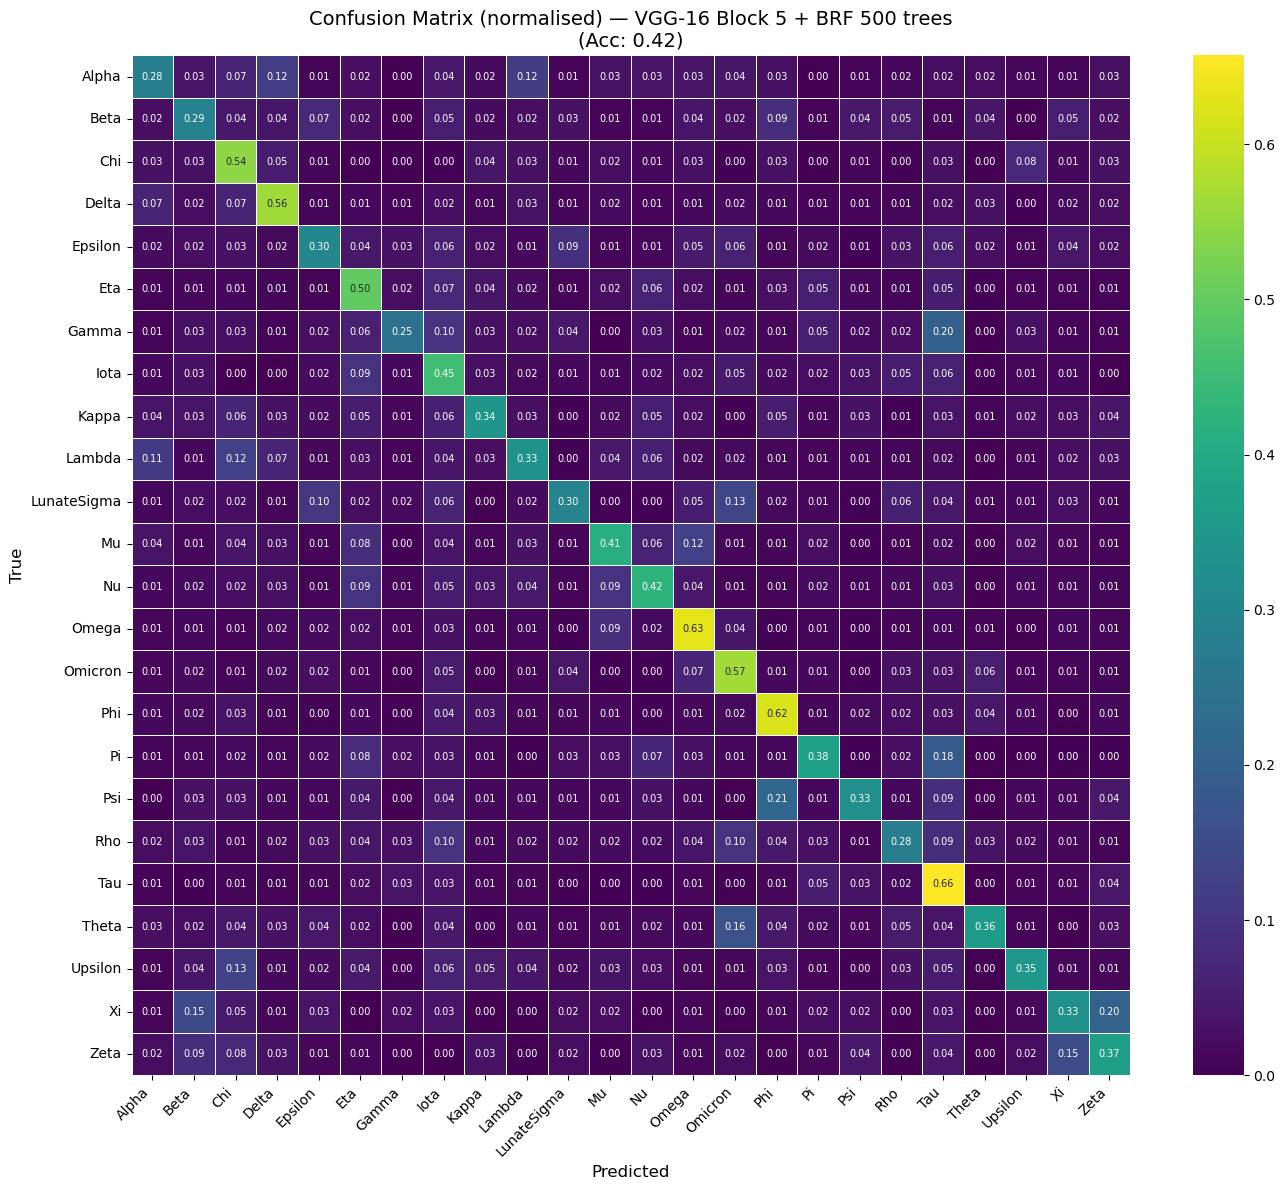

In [2]:
#8.1 
"""
Balanced Random Forest Classifier for Greek Letters
---------------------------------------------------
Loads the 512-d VGG-16 block 5 features and trains a BalancedRandomForestClassifier.
Class imbalance is handled via balanced bootstrap sampling.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block5pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block5pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         500,          # number of trees
    "min_samples_leaf":     1,            # default; leaf must have ≥1 sample
    "max_features":         "sqrt",       # default for RF classifiers
    "max_depth":            None,         # unlimited tree depth (default)
    "n_jobs":               -1,           # use all CPU cores

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          5,            # VGG-16 cut point
    "feature_dim":          512,          # 512 for block5

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap", # Strategy used by BRF
    "smote_target":         None,                 # None — SMOTE not used in this run

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,         # 80% train, 20% test
    "random_state":         42,           # fixed seed for full reproducibility
    "leakage_free_scaling": True,         # True = split first, then scale
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────

wandb.init(
    project  = "odysseus",
    name     = "BRF_block5_bootstrap_trees500",   # convention: {type}_block{N}_{strategy}_trees{N}
    job_type = "modeling",
    config   = config_params
)

config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 512)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

print("\nScaling features...")

scaler        = StandardScaler()
X_train       = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test        = scaler.transform(X_test)        # apply train statistics to test only


# ── Step 4: Train Balanced Random Forest ───────────────────────────────────────

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

rf = BalancedRandomForestClassifier(
    n_estimators = config.n_estimators,   # tracked: 500 trees
    random_state = config.random_state,   # tracked: 42
    n_jobs       = config.n_jobs          # tracked: -1 (all cores)
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")

print(f"Saved: random_forest.pkl and scaler.pkl to {OUTPUT_DIR}/")


# ── 10. Generate and Log Annotated Heatmap ────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,            
    fmt          = ".2f",           
    cmap         = "viridis",       
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},     
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 5 + BRF {config.n_estimators} trees\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

CM_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})
wandb.finish()

plt.show()

Starting...


Loading features and labels...
Features shape : (55329, 512)
Labels shape   : (55329,)
Train set : 44263 images
Test set  : 11066 images

Scaling features...

Training Balanced Random Forest (this may take a few minutes)...
Training done.

Evaluating on test set...
Overall accuracy : 41.58%
Macro-F1         : 0.3739
Weighted-F1      : 0.4211
Worst class      : Zeta (F1 = 0.1845)

Per-class report:
              precision    recall  f1-score   support

       Alpha       0.59      0.27      0.37      1043
        Beta       0.15      0.30      0.20       164
         Chi       0.31      0.54      0.39       303
       Delta       0.40      0.59      0.48       376
     Epsilon       0.51      0.31      0.39       784
         Eta       0.39      0.49      0.43       532
       Gamma       0.22      0.24      0.23       166
        Iota       0.28      0.43      0.34       433
       Kappa       0.53      0.35      0.42       585
      Lambda       0.26      0.33      0.29       354
 Lun

final_accuracy,0.41578
final_macro_f1,0.37391
final_weighted_f1,0.42109
final_worst_class_f1,0.18447
final_worst_class_name,Zeta
n_test_samples,11066
n_train_samples,44263


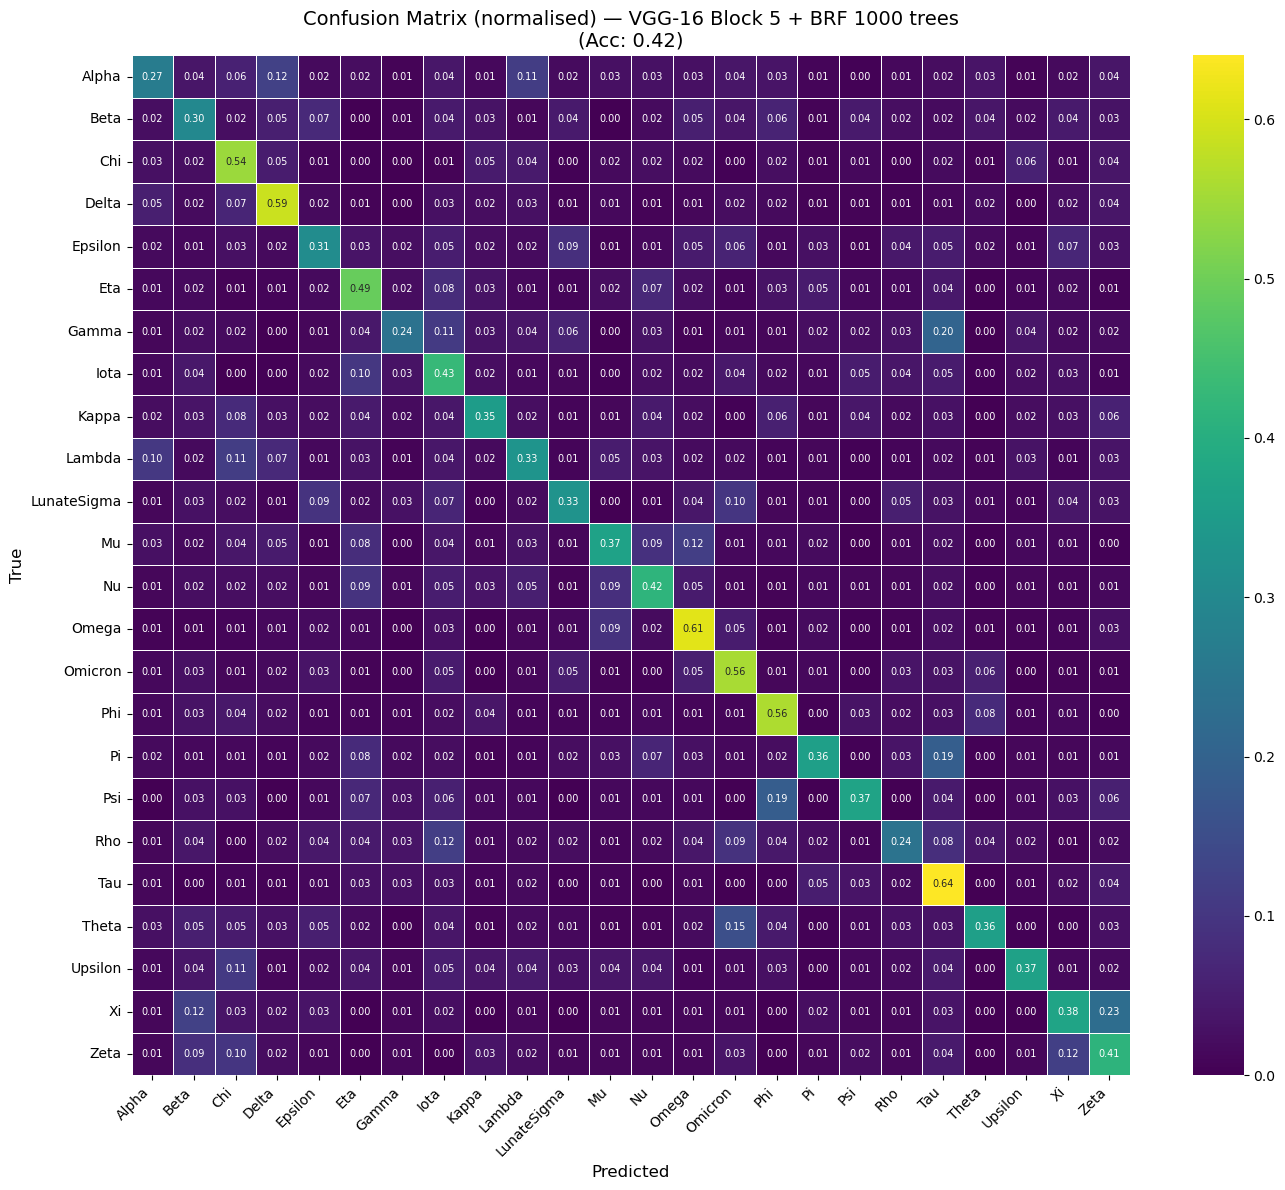

In [3]:
#9.1

"""
Balanced Random Forest Classifier for Greek Letters (Tuned)
-----------------------------------------------------------
Loads the 512-d VGG-16 block 5 features and trains a BalancedRandomForestClassifier.
Includes hyperparameter tuning (1000 trees, 0.3 max features, min_samples_leaf=2)
to provide stable votes for minority classes.
Outputs: model, scaler, and a classification report.
"""

import json
import os
import numpy as np
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib


# ── Settings ───────────────────────────────────────────────────────────────────

FEATURES_FILE    = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/features_block5pool.npy"
LABELS_FILE      = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/labels_block5pool.npy"
CLASS_INDEX_FILE = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT/class_indices.json"
OUTPUT_DIR       = "C:/Users/niric/Desktop/classes/AI and ML/CLEAN_DATASET/OUTPUT"


# ── 1. Define hyperparameters centrally for W&B Config Tracking ────────────────
#
# This dictionary will populate the "Overview" tab in your W&B dashboard.
# Every key here becomes a searchable, comparable column across all your runs,
# letting you filter and sort across your two main experiment axes:
#   • VGG-16 cut point  (block3 / block4 / block5)
#   • Classifier type   (RandomForest / BalancedRandomForest)
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "model_type"    → was "SVC", now "BalancedRandomForestClassifier"
#   "n_estimators"  → replaces "kernel"/"C"/"gamma" (not applicable to RF)
#   "class_weight"  → removed; BRF handles imbalance natively via balanced bootstrap
#   "n_jobs"        → replaces "cache_size" (RF uses CPU cores, not RAM cache)
#   "test_size"     → kept identical; same split ratio
#   "random_state"  → kept identical; same reproducibility seed
#   "vgg16_block"   → kept identical; block cut point
#
# ── New keys (added to make all 10 runs comparable in the dashboard) ──────────
#   "feature_dim"          → 256 for block3, 512 for block4/block5.
#                            Flows from the block choice; lets you immediately
#                            see how input size correlates with performance.
#
#   "imbalance_strategy"   → one of: "class_weight" | "balanced_bootstrap" |
#                            "smote+balanced_subsample".
#                            You used three different approaches across runs —
#                            without this key they look identical in the table.
#
#   "smote_target"         → the minority-class sample target when SMOTE is used
#                            (2000 in runs 2 & 3), or None when not used.
#                            Lets you see whether the synthetic data volume
#                            affected results independently of the classifier.
#
#   "min_samples_leaf"     → varied across runs (1, 2, 4, 8). Controls how
#                            fine-grained the leaf nodes are — higher values
#                            smooth decision boundaries and reduce overfitting.
#                            Currently invisible in W&B without this key.
#
#   "max_features"         → varied across runs ("sqrt", "log2", 0.3, None).
#                            Controls how many features each split considers.
#                            Directly affects tree diversity and generalisation.
#
#   "max_depth"            → None (unlimited) in most runs, 25 in run 3.
#                            Without logging this you cannot tell which runs
#                            had depth-capped trees vs fully grown ones.
#
#   "leakage_free_scaling" → True in this script (split before scale).
#                            False in all original scripts (scale before split).
#                            Critical for interpreting metric differences across
#                            runs — a run with leakage will appear artificially
#                            better than one without.

config_params = {
    # ── Model identity ─────────────────────────────────────────────────────────
    "model_type":           "BalancedRandomForestClassifier",
    "n_estimators":         1000,         # 500 -> 1000: more stable votes
    "min_samples_leaf":     2,            # 1 -> 2: smooths noisy splits
    "max_features":         0.3,          # considers ~154/512 features per split
    "max_depth":            None,         # unlimited tree depth (default)
    "n_jobs":               -1,           # use all CPU cores

    # ── Feature source ─────────────────────────────────────────────────────────
    "vgg16_block":          5,            # VGG-16 cut point (3 / 4 / 5)
    "feature_dim":          512,          # 256 for block3, 512 for block5

    # ── Imbalance handling ─────────────────────────────────────────────────────
    "imbalance_strategy":   "balanced_bootstrap", # "class_weight" | "balanced_bootstrap"
                                                  # | "smote+balanced_subsample"
    "smote_target":         None,                 # None — SMOTE not used in this run

    # ── Data split & reproducibility ───────────────────────────────────────────
    "test_size":            0.20,         # 80% train, 20% test
    "random_state":         42,           # fixed seed for full reproducibility
    "leakage_free_scaling": True,         # True = split first, then scale (correct)
                                          # False = original scripts (data leakage)
}


# ── 2. Initialize Weights & Biases with the config dictionary ──────────────────
#
# "project"   → unchanged: groups all runs under one project.
#
# "name"      → updated to follow a consistent convention across all 10 runs:
#               {model_type}_block{vgg16_block}_{imbalance_strategy}_trees{n_estimators}
#
#               This makes the runs table immediately readable — you can see
#               at a glance which block, which classifier, and which imbalance
#               strategy each run used without opening it.
#
#               Examples from your other scripts:
#                 RF_block3_classweight_trees500         
#                 BRF_block3_smote_trees500
#                 BRF_block3_smote_trees700
#                 RF_block4_classweight_trees500
#                 BRF_block4_bootstrap_trees500
#                 BRF_block4_bootstrap_trees1000         ← this run
#                 BRF_block5_bootstrap_trees500
#                 RF_block5_classweight_trees500
#
# "job_type"  → unchanged: "modeling" tags this as a training run.
# "config"    → unchanged: passes all hyperparameters from the first line.

print("Starting...")

wandb.init(
    project  = "odysseus",
    name     = "BRF_block5_bootstrap_trees1000_1",   # convention: {type}_block{N}_{strategy}_trees{N}
    job_type = "modeling",
    config   = config_params
)

# Map the tracked config back to a local variable for clean instantiation.
# If a W&B sweep overrides a value (e.g. sets n_estimators=1500),
# this variable will reflect that override — not the original dict above.
config = wandb.config


# ── Step 1: Load data ──────────────────────────────────────────────────────────

print("Loading features and labels...")

features = np.load(FEATURES_FILE)   # shape: (55329, 512)
labels   = np.load(LABELS_FILE)     # shape: (55329,)

with open(CLASS_INDEX_FILE) as f:
    class_indices = json.load(f)

# Reverse the dict so we can go from integer → letter name
# e.g. {0: "Alpha", 1: "Beta", ...}
index_to_class = {v: k for k, v in class_indices.items()}
class_names    = [index_to_class[i] for i in range(len(class_indices))]

print(f"Features shape : {features.shape}")
print(f"Labels shape   : {labels.shape}")


# ── Step 2: Train / test split ────────────────────────────────────────────────

# stratify=labels ensures each class keeps its original proportion in both splits.
# e.g. if Psi is 0.6% of total, it stays 0.6% in both train and test.
# test_size and random_state are read from config (W&B-tracked) rather than
# hard-coded — same pattern as the colleague's code.
#
# The split happens BEFORE scaling (see Step 3).
# This is the correct order — see the explanation below.

X_train, X_test, y_train, y_test = train_test_split(
    features, labels,
    test_size    = config.test_size,      # tracked: 0.20
    random_state = config.random_state,   # tracked: 42
    stratify     = labels
)

print(f"Train set : {X_train.shape[0]} images")
print(f"Test set  : {X_test.shape[0]} images")


# ── Step 3: Scale features ─────────────────────────────────────────────────────

# WHAT IS A SCALER?
# -----------------
# Your 512 VGG-16 features have very different numeric ranges — some sit near 0,
# others can reach ~3462. A StandardScaler is a per-feature normaliser: for each
# of the 512 columns it computes the mean and standard deviation across all
# training samples, then subtracts the mean and divides by the std.
# The result is that every feature ends up with mean ≈ 0 and std ≈ 1.
# This puts all 512 features on equal footing so no single large-valued feature
# dominates the model's decision-making.
#
# WHY THE ORDER MATTERS (data leakage fix):
# -----------------------------------------
# Previously, scaler.fit_transform(features) was called on the FULL dataset
# before the split. That means the scaler's mean/std were computed using test
# samples too — the model was indirectly "peeking" at test data during training.
# This is called data leakage and causes over-optimistic metrics at evaluation.
#
# The correct order (used here, and by the colleague's code) is:
#   1. fit_transform on X_train → scaler learns mean/std from training data only
#   2. transform on X_test      → applies those SAME training statistics to test
#
# The test set is treated as if it were brand-new, unseen data — which is what
# it should simulate.

print("\nScaling features...")

scaler        = StandardScaler()
X_train       = scaler.fit_transform(X_train)   # learn from train, then scale it
X_test        = scaler.transform(X_test)        # apply train statistics to test only


# ── Step 4: Train Balanced Random Forest ───────────────────────────────────────

# All constructor arguments come from config (W&B-tracked) rather than
# magic numbers — same discipline as the colleague's SVC instantiation.
# BalancedRandomForestClassifier handles imbalance naturally via balanced 
# bootstrap samples, ensuring rare classes get equal representation in every tree.

print("\nTraining Balanced Random Forest (this may take a few minutes)...")

rf = BalancedRandomForestClassifier(
    n_estimators     = config.n_estimators,     # tracked: 1000 trees
    max_features     = config.max_features,     # tracked: 0.3
    min_samples_leaf = config.min_samples_leaf, # tracked: 2
    random_state     = config.random_state,     # tracked: 42
    n_jobs           = config.n_jobs            # tracked: -1 (all cores)
)

rf.fit(X_train, y_train)
print("Training done.")


# ── Step 5: Evaluate ───────────────────────────────────────────────────────────

print("\nEvaluating on test set...")
y_pred = rf.predict(X_test)

# Compute all metrics using sklearn functions (consistent with colleague's style)
accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

# Per-class F1 — array of length 24, one score per Greek letter.
# Used below for two purposes:
#   1. Logged as a W&B Table so you can compare every class across all runs.
#   2. Identifies the single worst-performing class, which is more informative
#      than macro F1 alone for catching a completely abandoned minority class.
per_class_f1     = f1_score(y_test, y_pred, average=None)
worst_class_idx  = per_class_f1.argmin()
worst_class_f1   = per_class_f1[worst_class_idx]
worst_class_name = class_names[worst_class_idx]

print(f"Overall accuracy : {accuracy * 100:.2f}%")
print(f"Macro-F1         : {macro_f1:.4f}")
print(f"Weighted-F1      : {weighted_f1:.4f}")
print(f"Worst class      : {worst_class_name} (F1 = {worst_class_f1:.4f})")

# Per-class precision, recall and F1 — important for imbalanced datasets.
# A high overall accuracy can hide poor performance on rare classes.
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=class_names))


# ── Log Final Summary Metrics to W&B ──────────────────────────────────────────
#
# wandb.run.summary permanently pins these scalars to the run-table in the
# W&B dashboard — they stay visible even after the run finishes and let you
# sort/compare all runs at a glance.
#
# ── Original keys (from colleague's pattern) ──────────────────────────────────
#   "final_accuracy"    → overall fraction of correctly classified test samples
#   "final_macro_f1"    → average F1 across all 24 classes (equal class weight)
#   "final_weighted_f1" → average F1 weighted by class size
#
# ── New keys ──────────────────────────────────────────────────────────────────
#   "final_worst_class_f1"   → F1 of the single worst-performing class.
#                              Since you care about rare classes (Psi, Xi),
#                              this pinpoints whether any class is being
#                              abandoned even when macro F1 looks acceptable.
#
#   "final_worst_class_name" → Name of that class (e.g. "Psi", "Xi").
#                              Lets you see in the runs table whether it's
#                              always the same letter struggling across blocks
#                              and classifier types.
#
#   "n_train_samples"        → Training set size AFTER any SMOTE upsampling.
#                              Runs with SMOTE have more samples than runs
#                              without — logging this lets you separate the
#                              effect of data volume from model choice.
#
#   "n_test_samples"         → Test set size. Should be ~11066 across all runs
#                              (20% of 55329) — logging it confirms consistency.

wandb.run.summary["final_accuracy"]         = accuracy
wandb.run.summary["final_macro_f1"]         = macro_f1
wandb.run.summary["final_weighted_f1"]      = weighted_f1
wandb.run.summary["final_worst_class_f1"]   = worst_class_f1
wandb.run.summary["final_worst_class_name"] = worst_class_name
wandb.run.summary["n_train_samples"]        = X_train.shape[0]
wandb.run.summary["n_test_samples"]         = X_test.shape[0]


# ── Log Per-Class F1 Table to W&B ─────────────────────────────────────────────
#
# wandb.Table creates an interactive table visible in the W&B run page.
# Each row is one Greek letter and its F1 score for this run.
#
# Why this matters: the classification_report above only prints to terminal
# and is lost after the run. The W&B Table persists and — crucially — lets
# you open two runs side by side and see exactly which letters improved or
# regressed when you changed the block or classifier. This is the most
# useful addition for your specific experiment structure.
#
# wandb.log (not .summary) is correct here: Tables are media objects,
# same pattern as the confusion matrix image below.

per_class_table = wandb.Table(columns=["class", "f1"])
for name, score in zip(class_names, per_class_f1):
    per_class_table.add_data(name, round(float(score), 4))
wandb.log({"per_class_f1_table": per_class_table})


# ── Step 6: Save model and scaler ─────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(rf,     f"{OUTPUT_DIR}/random_forest.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")

print(f"Saved: random_forest.pkl and scaler.pkl to {OUTPUT_DIR}/")


# ── 10. Generate and Log Annotated Heatmap ────────────────────────────────────
#
# confusion_matrix returns a 24×24 grid where:
#   rows = true class, columns = predicted class
#   diagonal = correct predictions, off-diagonal = mistakes
# Normalise each row to 0–1 so all classes are comparable regardless of size
# (without this, Alpha's large count would visually dominate the rare classes).
#
# cmap change: "Blues" (white→blue) → "viridis" (dark purple→green→yellow).
# "viridis" is perceptually uniform and works well for normalised matrices —
# low values (misclassifications) appear dark purple, high values (correct
# predictions) appear bright yellow.

cm = confusion_matrix(y_test, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    cm_normalised,
    annot        = True,             # show the probability inside each cell
    fmt          = ".2f",            # 2 decimal places
    cmap         = "viridis",        # dark purple (0) → yellow (1)
    xticklabels  = class_names,
    yticklabels  = class_names,
    linewidths   = 0.5,
    annot_kws    = {"size": 7},      # keeps numbers readable across all 576 cells
    ax           = ax
)

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(
    f"Confusion Matrix (normalised) — VGG-16 Block 5 + BRF {config.n_estimators} trees\n"
    f"(Acc: {accuracy:.2f})",
    fontsize=14
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Save to disk first, then log to W&B as an Image artifact.
# wandb.log (not .summary) is correct here — files/images are logged
# this way in the colleague's code and it keeps the image browsable in the
# W&B Media panel.
CM_PATH = f"{OUTPUT_DIR}/confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150)
print(f"Saved: confusion_matrix.png to {OUTPUT_DIR}/")

wandb.log({"confusion_matrix_annotated": wandb.Image(CM_PATH)})

# ── Close the W&B run ─────────────────────────────────────────────────────────
# wandb.finish() is called BEFORE plt.show() intentionally.
# plt.show() can block execution in non-interactive / server environments,
# which would leave the W&B run permanently open (zombie run in the dashboard).
# The PNG is already saved and logged above, so finishing here is safe.
wandb.finish()

plt.show()


# ── To predict a new image later ───────────────────────────────────────────────
#
#   rf     = joblib.load("OUTPUT/random_forest.pkl")
#   scaler = joblib.load("OUTPUT/scaler.pkl")
#
#   feature_vector = ...            # your 512-d vector from the extractor
#   feature_scaled = scaler.transform([feature_vector])
#   prediction     = rf.predict(feature_scaled)
#   print(class_names[prediction[0]])